<a href="https://colab.research.google.com/github/grupopmacs-collab/Taller-3.4.-Reconocimiento-facial/blob/main/Copia_de_Taller_Reconocimento_Facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 ANÁLISIS EXPLORATORIO - RECONOCIMIENTO FACIAL
EQUIPO:
  • Lizarraga Aliaga Alexis Joaquin
  • Huaychi Sencia José Natividad
  • Challco Ccohuanqui Samir Junior
  • Tejada Taco Francys Raul
  • Zavala Huacarpuma Juan Aldair
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado correctamente

           REPORTE COMPLETO - RECONOCIMIENTO FACIAL

=== ESTRUCTURA REQUERIDA EN GOOGLE DRIVE ===
Tu Google Drive debe tener esta estructura exacta:

Google Drive/
└── MyDrive/
    └── dataset_facial/
        ├── Lizarraga_Aliaga_Alexis_Joaquin/
        │   ├── foto1.jpg
        │   ├── foto2.jpg
        │   └── ... (mínimo 100 imágenes)
        ├── Huaychi_Sencia_Jose_Natividad/
        │   ├── foto1.jpg
        │   ├── foto2.jpg
        │   └── ... (mínimo 100 imágenes)
        ├── Challco_Ccohuanqui_Samir_Junior/
        │   ├── foto1.jpg
        │   ├── foto2.jpg
        │   └── ... (mínimo 100 im

/tmp/ipython-input-41767891.py:318: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


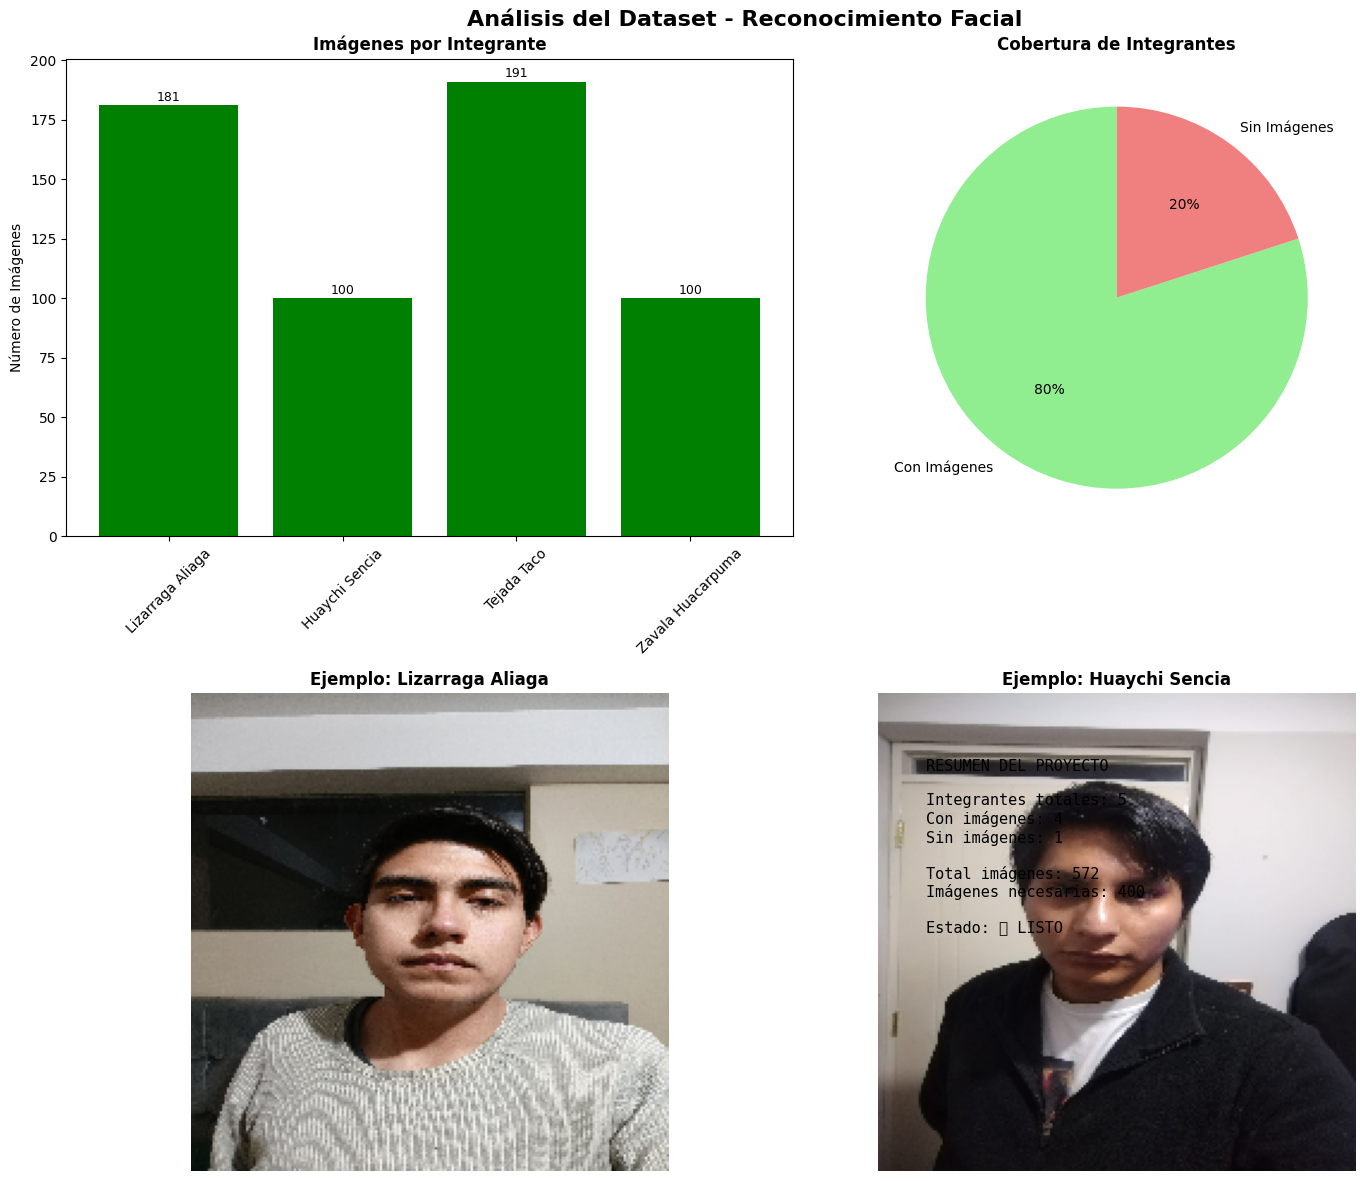


🎯 PRÓXIMOS PASOS:
✅ Puedes proceder con el preprocesamiento de imágenes
💡 Ejecuta este código nuevamente cuando agregues más imágenes

🔄 Para actualizar: Agrega imágenes y ejecuta este mismo código


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

class FacialRecognitionEDA:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.estadisticas = {}
        self.imagenes_ejemplo = {}

        # Lista oficial de integrantes del equipo
        self.integrantes_oficiales = [
            "Lizarraga_Aliaga_Alexis_Joaquin",
            "Huaychi_Sencia_Jose_Natividad",
            "Challco_Ccohuanqui_Samir_Junior",
            "Tejada_Taco_Francys_Raul",
            "Zavala_Huacarpuma_Juan_Aldair"
        ]

    def verificar_integrantes_con_imagenes(self):
        """Verifica qué integrantes tienen imágenes disponibles"""
        print("=== VERIFICACIÓN DE INTEGRANTES CON IMÁGENES ===")

        integrantes_con_imagenes = []
        integrantes_sin_imagenes = []

        for integrante in self.integrantes_oficiales:
            integrante_path = os.path.join(self.dataset_path, integrante)
            if os.path.exists(integrante_path) and os.path.isdir(integrante_path):
                imagenes = [f for f in os.listdir(integrante_path)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imagenes:
                    integrantes_con_imagenes.append(integrante)
                else:
                    integrantes_sin_imagenes.append(integrante)
            else:
                integrantes_sin_imagenes.append(integrante)

        self.estadisticas['integrantes_con_imagenes'] = integrantes_con_imagenes
        self.estadisticas['integrantes_sin_imagenes'] = integrantes_sin_imagenes
        self.estadisticas['total_con_imagenes'] = len(integrantes_con_imagenes)
        self.estadisticas['total_sin_imagenes'] = len(integrantes_sin_imagenes)

        print("✅ INTEGRANTES CON IMÁGENES:")
        for integrante in integrantes_con_imagenes:
            print(f"   - {integrante}")

        if integrantes_sin_imagenes:
            print("\n❌ INTEGRANTES SIN IMÁGENES (FALTANTES):")
            for integrante in integrantes_sin_imagenes:
                print(f"   - {integrante}")

        return integrantes_con_imagenes, integrantes_sin_imagenes

    def verificar_estructura_dataset(self):
        """Muestra la estructura esperada con nombres reales"""
        print("\n=== ESTRUCTURA REQUERIDA EN GOOGLE DRIVE ===")
        print("Tu Google Drive debe tener esta estructura exacta:\n")

        print("Google Drive/")
        print("└── MyDrive/")
        print("    └── dataset_facial/")
        for i, integrante in enumerate(self.integrantes_oficiales[:3], 1):
            print(f"        ├── {integrante}/")
            print(f"        │   ├── foto1.jpg")
            print(f"        │   ├── foto2.jpg")
            print(f"        │   └── ... (mínimo 100 imágenes)")
        print("        ├── ... (otros integrantes)")
        print("        └── [integrantes faltantes se crearán automáticamente]")

        input("\nPresiona Enter para continuar con el análisis...")

    def crear_estructura_faltante(self):
        """Crea carpetas para integrantes que no existen"""
        print("\n=== CREANDO ESTRUCTURA PARA INTEGRANTES FALTANTES ===")

        creados = []
        for integrante in self.estadisticas['integrantes_sin_imagenes']:
            integrante_path = os.path.join(self.dataset_path, integrante)
            if not os.path.exists(integrante_path):
                os.makedirs(integrante_path, exist_ok=True)
                creados.append(integrante)
                print(f"✅ Carpeta creada: {integrante}")

        if creados:
            print(f"\n📁 Se crearon {len(creados)} carpetas para integrantes faltantes")
            print("💡 Ahora puedes subir las imágenes a estas carpetas")
        else:
            print("✅ Todas las carpetas de integrantes ya existen")

        return creados

    def analizar_estructura_dataset(self):
        """Analiza la estructura y organización del dataset"""
        print("\n=== ANÁLISIS DETALLADO POR INTEGRANTE ===")

        estructura = {}
        total_imagenes = 0

        for integrante in self.estadisticas['integrantes_con_imagenes']:
            integrante_path = os.path.join(self.dataset_path, integrante)
            imagenes = [f for f in os.listdir(integrante_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            num_imagenes = len(imagenes)
            estructura[integrante] = num_imagenes
            total_imagenes += num_imagenes

            # Guardar imagen de ejemplo
            if imagenes:
                self.imagenes_ejemplo[integrante] = os.path.join(integrante_path, imagenes[0])

        self.estadisticas['estructura'] = estructura
        self.estadisticas['total_imagenes'] = total_imagenes
        self.estadisticas['balance'] = self._calcular_balance(estructura)

        print("📊 RESUMEN POR INTEGRANTE:")
        for integrante, count in estructura.items():
            # Formatear nombre para mejor visualización
            nombre_corto = self._acortar_nombre(integrante)
            estado = "✅ SUFICIENTE" if count >= 100 else "⚠️  INSUFICIENTE"
            progreso = "█" * min(count // 20, 5)  # Barra de progreso
            print(f"   {nombre_corto:<25} {count:>3} imágenes {progreso:<5} {estado}")

        print(f"\n📈 Total de imágenes en dataset: {total_imagenes}")
        print(f"🎯 Objetivo mínimo: {len(self.estadisticas['integrantes_con_imagenes'])} integrantes × 100 = {len(self.estadisticas['integrantes_con_imagenes']) * 100} imágenes")

        return estructura

    def _acortar_nombre(self, nombre_completo):
        """Acorta el nombre para mejor visualización"""
        partes = nombre_completo.split('_')
        if len(partes) >= 2:
            return f"{partes[0]} {partes[1]}"
        return nombre_completo

    def _calcular_balance(self, estructura):
        """Calcula qué tan balanceado está el dataset"""
        counts = list(estructura.values())
        if not counts:
            return 0
        balance_ratio = min(counts) / max(counts) if max(counts) > 0 else 0
        return balance_ratio

    def analizar_caracteristicas_imagenes(self):
        """Analiza dimensiones y características de las imágenes"""
        print("\n=== ANÁLISIS DE CALIDAD DE IMÁGENES ===")

        dimensiones = []
        canales = []

        for integrante in self.estadisticas['integrantes_con_imagenes'][:3]:  # Muestra de 3 integrantes
            integrante_path = os.path.join(self.dataset_path, integrante)
            imagenes = [f for f in os.listdir(integrante_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            for img_file in imagenes[:10]:  # 10 imágenes por integrante
                img_path = os.path.join(integrante_path, img_file)
                img = cv2.imread(img_path)

                if img is not None:
                    h, w, c = img.shape
                    dimensiones.append((w, h))
                    canales.append(c)

        if dimensiones:
            dimensiones = np.array(dimensiones)
            self.estadisticas['dimensiones_promedio'] = dimensiones.mean(axis=0)
            self.estadisticas['dimensiones_min'] = dimensiones.min(axis=0)
            self.estadisticas['dimensiones_max'] = dimensiones.max(axis=0)

            print(f"✓ Dimensiones promedio: {self.estadisticas['dimensiones_promedio'][0]:.0f} × {self.estadisticas['dimensiones_promedio'][1]:.0f} px")
            print(f"✓ Rango de dimensiones: {self.estadisticas['dimensiones_min'][0]:.0f}×{self.estadisticas['dimensiones_min'][1]:.0f} a {self.estadisticas['dimensiones_max'][0]:.0f}×{self.estadisticas['dimensiones_max'][1]:.0f}")

            # Evaluar calidad basada en dimensiones
            dim_promedio = self.estadisticas['dimensiones_promedio'][0]
            if dim_promedio >= 500:
                calidad = "✅ ALTA"
            elif dim_promedio >= 300:
                calidad = "✅ ADECUADA"
            else:
                calidad = "⚠️  BAJA"
            print(f"✓ Calidad de resolución: {calidad}")

        return dimensiones

    def generar_reporte_completo(self):
        """Genera un reporte completo del EDA"""
        print("\n" + "="*70)
        print("           REPORTE COMPLETO - RECONOCIMIENTO FACIAL")
        print("="*70)

        # Configuración inicial
        self.verificar_estructura_dataset()
        integrantes_con, integrantes_sin = self.verificar_integrantes_con_imagenes()

        # Crear estructura faltante si es necesario
        if integrantes_sin:
            self.crear_estructura_faltante()

        if not integrantes_con:
            print("\n❌ No se encontraron imágenes para ningún integrante")
            print("💡 Por favor, sube imágenes al menos para 3 integrantes")
            return self.estadisticas

        # Ejecutar análisis
        estructura = self.analizar_estructura_dataset()
        self.analizar_caracteristicas_imagenes()

        # Evaluación final
        print("\n" + "="*50)
        print("EVALUACIÓN FINAL DEL PROYECTO")
        print("="*50)

        total_integrantes = len(integrantes_con)
        imagenes_por_integrante = list(estructura.values())
        integrantes_completos = sum(1 for img in imagenes_por_integrante if img >= 100)

        print(f"✅ Integrantes con imágenes: {total_integrantes}/5")
        print(f"✅ Integrantes con 100+ imágenes: {integrantes_completos}/{total_integrantes}")
        print(f"✅ Total de imágenes: {self.estadisticas['total_imagenes']}")
        print(f"✅ Balance del dataset: {self.estadisticas['balance']:.2f}")

        # Determinar estado del proyecto
        if total_integrantes >= 3 and integrantes_completos >= 3:
            estado = "✅ LISTO PARA ENTRENAMIENTO"
        elif total_integrantes >= 3:
            estado = "🟡 EN PROGRESO (necesita más imágenes)"
        else:
            estado = "🔴 INCOMPLETO (necesita más integrantes)"

        print(f"\n🎯 ESTADO DEL PROYECTO: {estado}")

        # Recomendaciones específicas
        print("\n📋 RECOMENDACIONES:")
        for integrante, count in estructura.items():
            if count < 100:
                nombre_corto = self._acortar_nombre(integrante)
                print(f"   📸 {nombre_corto}: necesita {100 - count} imágenes más")

        if integrantes_sin:
            print(f"\n   👥 Integrantes faltantes: {len(integrantes_sin)}")
            for integrante in integrantes_sin:
                nombre_corto = self._acortar_nombre(integrante)
                print(f"      - {nombre_corto}")

        return self.estadisticas

    def visualizar_dataset(self):
        """Genera visualizaciones del dataset"""
        if not self.estadisticas.get('integrantes_con_imagenes'):
            print("No hay datos para visualizar")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Análisis del Dataset - Reconocimiento Facial', fontsize=16, fontweight='bold')

        # Gráfico 1: Distribución de imágenes por integrante
        if self.estadisticas.get('estructura'):
            integrantes = [self._acortar_nombre(name) for name in self.estadisticas['estructura'].keys()]
            counts = list(self.estadisticas['estructura'].values())

            colors = ['green' if count >= 100 else 'orange' for count in counts]
            bars = axes[0, 0].bar(integrantes, counts, color=colors)
            axes[0, 0].set_title('Imágenes por Integrante', fontweight='bold')
            axes[0, 0].set_ylabel('Número de Imágenes')
            axes[0, 0].tick_params(axis='x', rotation=45)

            # Añadir valores en las barras
            for bar, count in zip(bars, counts):
                axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                               f'{count}', ha='center', va='bottom', fontsize=9)

        # Gráfico 2: Estado del proyecto
        integrantes_con = self.estadisticas.get('total_con_imagenes', 0)
        integrantes_sin = self.estadisticas.get('total_sin_imagenes', 0)

        labels = ['Con Imágenes', 'Sin Imágenes']
        sizes = [integrantes_con, integrantes_sin]
        colors = ['lightgreen', 'lightcoral']

        axes[0, 1].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
        axes[0, 1].set_title('Cobertura de Integrantes', fontweight='bold')

        # Gráfico 3: Ejemplos de imágenes
        ejemplos = list(self.imagenes_ejemplo.items())[:2]
        for idx, (integrante, img_path) in enumerate(ejemplos):
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (200, 200))

                axes[1, idx].imshow(img_resized)
                nombre_corto = self._acortar_nombre(integrante)
                axes[1, idx].set_title(f'Ejemplo: {nombre_corto}', fontweight='bold')
                axes[1, idx].axis('off')

        # Información resumen
        axes[1, 1].axis('off')
        info_text = f"""
RESUMEN DEL PROYECTO

Integrantes totales: 5
Con imágenes: {integrantes_con}
Sin imágenes: {integrantes_sin}

Total imágenes: {self.estadisticas.get('total_imagenes', 0)}
Imágenes necesarias: {integrantes_con * 100}

Estado: {'✅ LISTO' if integrantes_con >= 3 and self.estadisticas.get('total_imagenes', 0) >= 300 else '🔄 EN PROGRESO'}
        """
        axes[1, 1].text(0.1, 0.9, info_text, transform=axes[1, 1].transAxes,
                       fontsize=11, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()
        plt.show()

# FUNCIÓN PRINCIPAL
def ejecutar_analisis_completo():
    """Función principal que ejecuta todo el análisis"""

    print("🔍 ANÁLISIS EXPLORATORIO - RECONOCIMIENTO FACIAL")
    print("="*60)
    print("EQUIPO:")
    print("  • Lizarraga Aliaga Alexis Joaquin")
    print("  • Huaychi Sencia José Natividad")
    print("  • Challco Ccohuanqui Samir Junior")
    print("  • Tejada Taco Francys Raul")
    print("  • Zavala Huacarpuma Juan Aldair")
    print("="*60)

    # Configurar rutas
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        base_path = '/content/drive/MyDrive/dataset_facial'
        print("✅ Google Drive montado correctamente")
    except:
        print("⚠️  Ejecutando en entorno local")
        base_path = './dataset_facial'

    # Verificar si existe el dataset
    if not os.path.exists(base_path):
        print(f"\n📁 Creando estructura base en: {base_path}")
        os.makedirs(base_path, exist_ok=True)

    # Ejecutar análisis
    eda = FacialRecognitionEDA(base_path)
    resultados = eda.generar_reporte_completo()

    if resultados.get('integrantes_con_imagenes'):
        eda.visualizar_dataset()

    print("\n🎯 PRÓXIMOS PASOS:")
    integrantes_con = resultados.get('total_con_imagenes', 0)
    if integrantes_con >= 3:
        print("✅ Puedes proceder con el preprocesamiento de imágenes")
        print("💡 Ejecuta este código nuevamente cuando agregues más imágenes")
    else:
        print("📝 Necesitas al menos 3 integrantes con imágenes para comenzar")

    print("\n🔄 Para actualizar: Agrega imágenes y ejecuta este mismo código")

# EJECUTAR EL ANÁLISIS
if __name__ == "__main__":
    ejecutar_analisis_completo()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado correctamente
🎯 INICIANDO FASE 3: PREPARACIÓN DE DATOS
=== VERIFICACIÓN FASE 2 ===
✅ Integrantes con imágenes: 4/5
   - Lizarraga_Aliaga_Alexis_Joaquin
   - Huaychi_Sencia_Jose_Natividad
   - Tejada_Taco_Francys_Raul
   - Zavala_Huacarpuma_Juan_Aldair

=== DETECCIÓN Y RECORTE FACIAL ===

🔍 Procesando: Lizarraga Aliaga
   Imágenes a procesar: 181
   Procesadas: 20/181
   Procesadas: 40/181
   Procesadas: 60/181
   Procesadas: 80/181
   Procesadas: 100/181
   Procesadas: 120/181
   Procesadas: 140/181
   Procesadas: 160/181
   Procesadas: 180/181

🔍 Procesando: Huaychi Sencia
   Imágenes a procesar: 100
   Procesadas: 20/100
   Procesadas: 40/100
   Procesadas: 60/100
   Procesadas: 80/100
   Procesadas: 100/100

🔍 Procesando: Challco Ccohuanqui
   Imágenes a procesar: 0

🔍 Procesando: Tejada Taco
   Imágenes a procesar: 191
   Procesadas

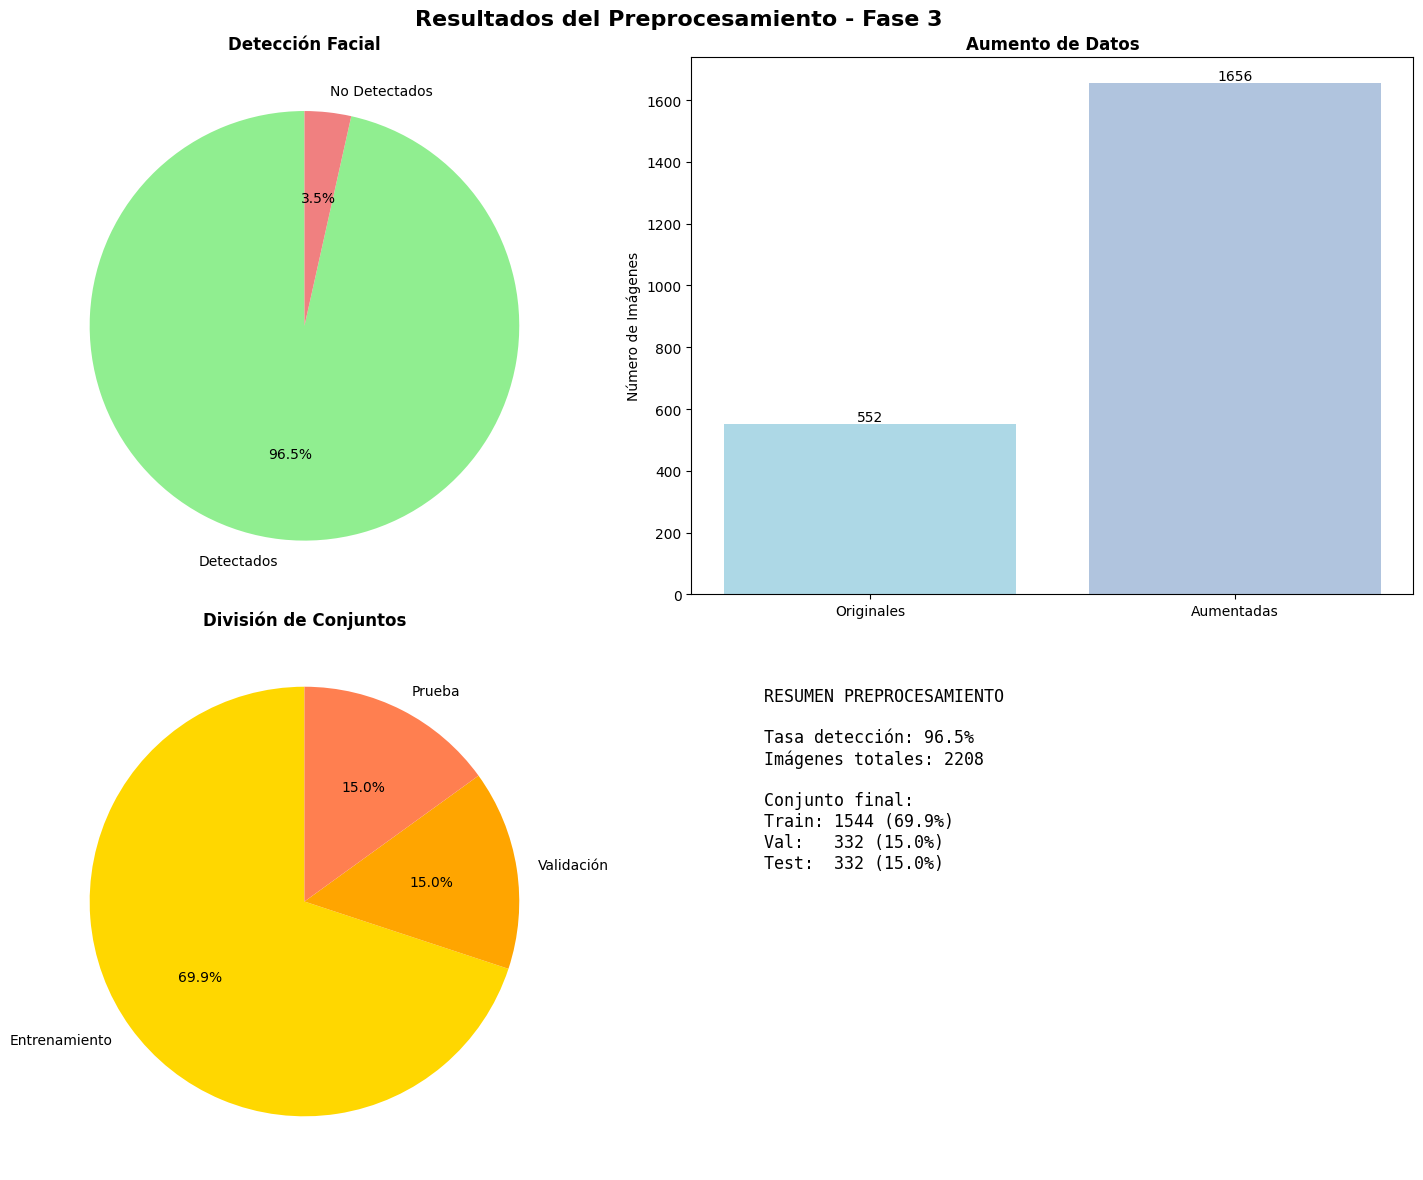


✅ FASE 3 COMPLETADA EXITOSAMENTE!
📁 Datasets finales en: /content/drive/MyDrive/datasets_finales

🎯 PRÓXIMOS PASOS:
1. Revisar las estadísticas de preprocesamiento
2. Verificar la calidad de los rostros detectados
3. Proceder con la Fase 4: Modelado
4. Los datasets están en: /content/drive/MyDrive/datasets_finales


In [ ]:
import os
import cv2
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class DataPreparer:
    def __init__(self, dataset_path, output_size=(224, 224)):
        self.dataset_path = dataset_path
        self.output_size = output_size
        self.preprocessed_path = os.path.join(os.path.dirname(dataset_path), 'dataset_preprocesado')
        self.augmented_path = os.path.join(os.path.dirname(dataset_path), 'dataset_aumentado')
        self.estadisticas_preprocesamiento = {}

        # Lista oficial de integrantes
        self.integrantes_oficiales = [
            "Lizarraga_Aliaga_Alexis_Joaquin",
            "Huaychi_Sencia_Jose_Natividad",
            "Challco_Ccohuanqui_Samir_Junior",
            "Tejada_Taco_Francys_Raul",
            "Zavala_Huacarpuma_Juan_Aldair"
        ]

    def verificar_fase_2(self):
        """Verifica que la Fase 2 se haya completado correctamente"""
        print("=== VERIFICACIÓN FASE 2 ===")

        if not os.path.exists(self.dataset_path):
            print(f"❌ No se encuentra el dataset: {self.dataset_path}")
            return False

        integrantes_con_imagenes = []
        for integrante in self.integrantes_oficiales:
            integrante_path = os.path.join(self.dataset_path, integrante)
            if os.path.exists(integrante_path):
                imagenes = [f for f in os.listdir(integrante_path)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imagenes:
                    integrantes_con_imagenes.append(integrante)

        print(f"✅ Integrantes con imágenes: {len(integrantes_con_imagenes)}/5")
        for integrante in integrantes_con_imagenes:
            print(f"   - {integrante}")

        if len(integrantes_con_imagenes) < 3:
            print("❌ Se necesitan al menos 3 integrantes con imágenes")
            return False

        return True

    def detectar_y_recortar_rostros(self):
        """Detección y recorte facial usando OpenCV"""
        print("\n=== DETECCIÓN Y RECORTE FACIAL ===")

        # Cargar detector de rostros
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

        rostros_detectados = 0
        rostros_no_detectados = 0

        # Crear directorio de salida
        if os.path.exists(self.preprocessed_path):
            shutil.rmtree(self.preprocessed_path)
        os.makedirs(self.preprocessed_path)

        for integrante in self.integrantes_oficiales:
            integrante_path = os.path.join(self.dataset_path, integrante)
            output_integrante_path = os.path.join(self.preprocessed_path, integrante)

            if not os.path.exists(integrante_path):
                continue

            os.makedirs(output_integrante_path, exist_ok=True)
            imagenes = [f for f in os.listdir(integrante_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            print(f"\n🔍 Procesando: {self._acortar_nombre(integrante)}")
            print(f"   Imágenes a procesar: {len(imagenes)}")

            for i, img_file in enumerate(imagenes):
                img_path = os.path.join(integrante_path, img_file)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                # Convertir a escala de grises para detección
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Detectar rostros
                faces = face_cascade.detectMultiScale(
                    gray,
                    scaleFactor=1.1,
                    minNeighbors=5,
                    minSize=(30, 30)
                )

                if len(faces) > 0:
                    # Tomar el rostro más grande
                    faces = sorted(faces, key=lambda x: x[2]*x[3], reverse=True)
                    x, y, w, h = faces[0]

                    # Expandir ligeramente el área del rostro
                    expand_x = int(w * 0.1)
                    expand_y = int(h * 0.1)
                    x = max(0, x - expand_x)
                    y = max(0, y - expand_y)
                    w = min(img.shape[1] - x, w + 2 * expand_x)
                    h = min(img.shape[0] - y, h + 2 * expand_y)

                    # Recortar y redimensionar
                    face = img[y:y+h, x:x+w]
                    face_resized = cv2.resize(face, self.output_size)

                    # Guardar rostro recortado
                    output_file = f"rostro_{i:03d}.jpg"
                    output_path = os.path.join(output_integrante_path, output_file)
                    cv2.imwrite(output_path, face_resized)

                    rostros_detectados += 1
                else:
                    rostros_no_detectados += 1

                # Mostrar progreso
                if (i + 1) % 20 == 0:
                    print(f"   Procesadas: {i + 1}/{len(imagenes)}")

        self.estadisticas_preprocesamiento['rostros_detectados'] = rostros_detectados
        self.estadisticas_preprocesamiento['rostros_no_detectados'] = rostros_no_detectados
        self.estadisticas_preprocesamiento['tasa_deteccion'] = rostros_detectados / (rostros_detectados + rostros_no_detectados) if (rostros_detectados + rostros_no_detectados) > 0 else 0

        print(f"\n📊 RESUMEN DETECCIÓN FACIAL:")
        print(f"   ✅ Rostros detectados: {rostros_detectados}")
        print(f"   ❌ Rostros no detectados: {rostros_no_detectados}")
        print(f"   📈 Tasa de detección: {self.estadisticas_preprocesamiento['tasa_deteccion']:.2%}")

        return rostros_detectados > 0

    def _acortar_nombre(self, nombre_completo):
        """Acorta el nombre para mejor visualización"""
        partes = nombre_completo.split('_')
        if len(partes) >= 2:
            return f"{partes[0]} {partes[1]}"
        return nombre_completo

    def aumentar_datos(self, factor_aumento=3):
        """Aplicar aumento de datos para balancear y robustecer"""
        print("\n=== AUMENTO DE DATOS ===")

        if not os.path.exists(self.preprocessed_path):
            print("❌ Primero debe ejecutar la detección facial")
            return False

        # Configurar generador de aumento
        datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            fill_mode='nearest'
        )

        # Crear directorio de aumento
        if os.path.exists(self.augmented_path):
            shutil.rmtree(self.augmented_path)
        os.makedirs(self.augmented_path)

        imagenes_originales_totales = 0
        imagenes_aumentadas_totales = 0

        for integrante in self.integrantes_oficiales:
            integrante_path = os.path.join(self.preprocessed_path, integrante)
            output_integrante_path = os.path.join(self.augmented_path, integrante)

            if not os.path.exists(integrante_path):
                continue

            os.makedirs(output_integrante_path, exist_ok=True)

            # Copiar imágenes originales
            imagenes = [f for f in os.listdir(integrante_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            for img_file in imagenes:
                src_path = os.path.join(integrante_path, img_file)
                dst_path = os.path.join(output_integrante_path, f"original_{img_file}")
                shutil.copy2(src_path, dst_path)

            imagenes_originales = len(imagenes)
            imagenes_originales_totales += imagenes_originales

            # Generar imágenes aumentadas
            target_imagenes = imagenes_originales * factor_aumento
            imagenes_generadas = 0

            for img_file in imagenes:
                if imagenes_generadas >= target_imagenes:
                    break

                img_path = os.path.join(integrante_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir a RGB
                img = img.reshape((1,) + img.shape)  # Añadir dimensión batch

                # Generar imágenes aumentadas
                for i, batch in enumerate(datagen.flow(img, batch_size=1)):
                    if imagenes_generadas >= target_imagenes:
                        break

                    augmented_img = batch[0].astype('uint8')
                    augmented_img_bgr = cv2.cvtColor(augmented_img, cv2.COLOR_RGB2BGR)

                    output_file = f"augmented_{img_file.split('.')[0]}_{i:02d}.jpg"
                    output_path = os.path.join(output_integrante_path, output_file)
                    cv2.imwrite(output_path, augmented_img_bgr)

                    imagenes_generadas += 1

            imagenes_aumentadas_totales += imagenes_generadas
            print(f"   {self._acortar_nombre(integrante)}: {imagenes_originales} → {imagenes_originales + imagenes_generadas} imágenes")

        self.estadisticas_preprocesamiento['imagenes_originales'] = imagenes_originales_totales
        self.estadisticas_preprocesamiento['imagenes_aumentadas'] = imagenes_aumentadas_totales
        self.estadisticas_preprocesamiento['total_con_aumento'] = imagenes_originales_totales + imagenes_aumentadas_totales

        print(f"\n📊 RESUMEN AUMENTO DE DATOS:")
        print(f"   📷 Imágenes originales: {imagenes_originales_totales}")
        print(f"   🎨 Imágenes aumentadas: {imagenes_aumentadas_totales}")
        print(f"   📈 Total después de aumento: {imagenes_originales_totales + imagenes_aumentadas_totales}")
        print(f"   🔁 Factor de aumento: {factor_aumento}x")

        return True

    def dividir_conjuntos(self, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
        """Dividir en conjuntos de entrenamiento, validación y prueba"""
        print("\n=== DIVISIÓN DE CONJUNTOS ===")

        dataset_source = self.augmented_path if os.path.exists(self.augmented_path) else self.preprocessed_path
        datasets_path = os.path.join(os.path.dirname(self.dataset_path), 'datasets_finales')

        # Crear estructura de directorios
        train_path = os.path.join(datasets_path, 'train')
        val_path = os.path.join(datasets_path, 'validation')
        test_path = os.path.join(datasets_path, 'test')

        # Limpiar y crear directorios
        if os.path.exists(datasets_path):
            shutil.rmtree(datasets_path)

        for split_path in [train_path, val_path, test_path]:
            for integrante in self.integrantes_oficiales:
                os.makedirs(os.path.join(split_path, integrante), exist_ok=True)

        estadisticas_division = {}

        for integrante in self.integrantes_oficiales:
            integrante_path = os.path.join(dataset_source, integrante)

            if not os.path.exists(integrante_path):
                continue

            imagenes = [f for f in os.listdir(integrante_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            if not imagenes:
                continue

            # Dividir imágenes
            train_files, temp_files = train_test_split(
                imagenes,
                test_size=(val_ratio + test_ratio),
                random_state=42,
                stratify=None
            )

            val_files, test_files = train_test_split(
                temp_files,
                test_size=test_ratio/(val_ratio + test_ratio),
                random_state=42
            )

            # Copiar archivos a sus directorios
            for file_list, dest_path in [
                (train_files, train_path),
                (val_files, val_path),
                (test_files, test_path)
            ]:
                for f in file_list:
                    src = os.path.join(integrante_path, f)
                    dst = os.path.join(dest_path, integrante, f)
                    shutil.copy2(src, dst)

            estadisticas_division[integrante] = {
                'train': len(train_files),
                'validation': len(val_files),
                'test': len(test_files),
                'total': len(imagenes)
            }

        # Generar reporte de división
        print("\n📊 DISTRIBUCIÓN FINAL DE DATOS:")
        print("Integrante                Train   Val   Test   Total")
        print("-" * 50)

        total_train = 0
        total_val = 0
        total_test = 0
        total_total = 0

        for integrante, stats in estadisticas_division.items():
            nombre_corto = self._acortar_nombre(integrante)
            print(f"{nombre_corto:<20} {stats['train']:>6} {stats['validation']:>5} {stats['test']:>5} {stats['total']:>6}")

            total_train += stats['train']
            total_val += stats['validation']
            total_test += stats['test']
            total_total += stats['total']

        print("-" * 50)
        print(f"{'TOTAL':<20} {total_train:>6} {total_val:>5} {total_test:>5} {total_total:>6}")

        # Calcular porcentajes
        print(f"\n📈 PORCENTAJES:")
        print(f"   Entrenamiento: {total_train/total_total:.1%} ({total_train} imágenes)")
        print(f"   Validación:    {total_val/total_total:.1%} ({total_val} imágenes)")
        print(f"   Prueba:        {total_test/total_total:.1%} ({total_test} imágenes)")

        self.estadisticas_preprocesamiento['division'] = estadisticas_division
        self.estadisticas_preprocesamiento['totales'] = {
            'train': total_train,
            'validation': total_val,
            'test': total_test,
            'total': total_total
        }

        return datasets_path

    def visualizar_preprocesamiento(self):
        """Visualizar resultados del preprocesamiento"""
        if not self.estadisticas_preprocesamiento:
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Resultados del Preprocesamiento - Fase 3', fontsize=16, fontweight='bold')

        # Gráfico 1: Detección facial
        if 'rostros_detectados' in self.estadisticas_preprocesamiento:
            detectados = self.estadisticas_preprocesamiento['rostros_detectados']
            no_detectados = self.estadisticas_preprocesamiento['rostros_no_detectados']

            labels = ['Detectados', 'No Detectados']
            sizes = [detectados, no_detectados]
            colors = ['lightgreen', 'lightcoral']

            axes[0, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
            axes[0, 0].set_title('Detección Facial', fontweight='bold')

        # Gráfico 2: Aumento de datos
        if 'imagenes_originales' in self.estadisticas_preprocesamiento:
            originales = self.estadisticas_preprocesamiento['imagenes_originales']
            aumentadas = self.estadisticas_preprocesamiento['imagenes_aumentadas']

            labels = ['Originales', 'Aumentadas']
            sizes = [originales, aumentadas]
            colors = ['lightblue', 'lightsteelblue']

            axes[0, 1].bar(labels, sizes, color=colors)
            axes[0, 1].set_title('Aumento de Datos', fontweight='bold')
            axes[0, 1].set_ylabel('Número de Imágenes')

            # Añadir valores en las barras
            for i, v in enumerate(sizes):
                axes[0, 1].text(i, v + 0.5, str(v), ha='center', va='bottom')

        # Gráfico 3: División de conjuntos
        if 'totales' in self.estadisticas_preprocesamiento:
            totales = self.estadisticas_preprocesamiento['totales']
            labels = ['Entrenamiento', 'Validación', 'Prueba']
            sizes = [totales['train'], totales['validation'], totales['test']]
            colors = ['gold', 'orange', 'coral']

            axes[1, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
            axes[1, 0].set_title('División de Conjuntos', fontweight='bold')

        # Información resumen
        axes[1, 1].axis('off')
        info_text = "RESUMEN PREPROCESAMIENTO\n\n"

        if 'tasa_deteccion' in self.estadisticas_preprocesamiento:
            info_text += f"Tasa detección: {self.estadisticas_preprocesamiento['tasa_deteccion']:.1%}\n"

        if 'total_con_aumento' in self.estadisticas_preprocesamiento:
            info_text += f"Imágenes totales: {self.estadisticas_preprocesamiento['total_con_aumento']}\n"

        if 'totales' in self.estadisticas_preprocesamiento:
            t = self.estadisticas_preprocesamiento['totales']
            info_text += f"\nConjunto final:\n"
            info_text += f"Train: {t['train']} ({t['train']/t['total']:.1%})\n"
            info_text += f"Val:   {t['validation']} ({t['validation']/t['total']:.1%})\n"
            info_text += f"Test:  {t['test']} ({t['test']/t['total']:.1%})\n"

        axes[1, 1].text(0.1, 0.9, info_text, transform=axes[1, 1].transAxes,
                       fontsize=12, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()
        plt.show()

    def ejecutar_fase_completa(self):
        """Ejecutar toda la Fase 3 de manera secuencial"""
        print("🎯 INICIANDO FASE 3: PREPARACIÓN DE DATOS")
        print("=" * 60)

        # Verificar Fase 2
        if not self.verificar_fase_2():
            print("❌ No se puede continuar. Ejecuta la Fase 2 primero.")
            return None

        # 1. Detección y recorte facial
        if not self.detectar_y_recortar_rostros():
            print("❌ Error en detección facial")
            return None

        # 2. Aumento de datos
        if not self.aumentar_datos(factor_aumento=3):
            print("❌ Error en aumento de datos")
            return None

        # 3. División de conjuntos
        datasets_path = self.dividir_conjuntos()

        # 4. Visualizar resultados
        self.visualizar_preprocesamiento()

        print("\n✅ FASE 3 COMPLETADA EXITOSAMENTE!")
        print(f"📁 Datasets finales en: {datasets_path}")

        return datasets_path

# FUNCIÓN PRINCIPAL
def ejecutar_fase_3():
    """Función principal para ejecutar la Fase 3"""

    # Configurar rutas (igual que Fase 2)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        base_path = '/content/drive/MyDrive/dataset_facial'
        print("✅ Google Drive montado correctamente")
    except:
        print("⚠️  Ejecutando en entorno local")
        base_path = './dataset_facial'

    # Ejecutar Fase 3 completa
    preparador = DataPreparer(base_path, output_size=(224, 224))
    datasets_path = preparador.ejecutar_fase_completa()

    if datasets_path:
        print(f"\n🎯 PRÓXIMOS PASOS:")
        print("1. Revisar las estadísticas de preprocesamiento")
        print("2. Verificar la calidad de los rostros detectados")
        print("3. Proceder con la Fase 4: Modelado")
        print(f"4. Los datasets están en: {datasets_path}")

    return datasets_path

# EJECUTAR FASE 3
if __name__ == "__main__":
    ejecutar_fase_3()

🔍 Verificando disponibilidad de GPU...
✅ GPU disponible: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
🎯 INICIANDO FASE 4: MODELADO
Mounted at /content/drive
✅ Google Drive montado correctamente
🔍 Detectadas 5 clases en el dataset
=== CONFIGURACIÓN DE GENERADORES DE DATOS ===
Found 1544 images belonging to 5 classes.
Found 332 images belonging to 5 classes.
Found 332 images belonging to 5 classes.
✅ Clases detectadas: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']
📊 Imágenes de entrenamiento: 1544
📊 Imágenes de validación: 332
📊 Imágenes de prueba: 332

=== CREACIÓN DEL MODELO ===
🔄 Cargando MobileNetV2 pre-entrenado...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base Model: MobileNetV2
✅ Capas congeladas: 154
✅ Modelo compilado exitosamente!
📈 Learning Rate: 0.001
🎯 Función de pérdida: Categorical Cross-Entropy
⚙️  Optimizador: Adam

=== ARQUI

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,054,661 (11.65 MB)

 Trainable params: 792,581 (3.02 MB)

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8489 - loss: 0.4211 - precision: 0.8805 - recall: 0.8241
Epoch 1: val_accuracy improved from -inf to 0.99398, saving model to best_model_20251104_074205.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 593s 12s/step - accuracy: 0.8509 - loss: 0.4158 - precision: 0.8822 - recall: 0.8264 - val_accuracy: 0.9940 - val_loss: 0.0510 - val_precision: 0.9939 - val_recall: 0.9880 - learning_rate: 0.0010
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9961 - loss: 0.0189 - precision: 0.9961 - recall: 0.9961
Epoch 2: val_accuracy did not improve from 0.99398
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 524ms/step - accuracy: 0.9961 - loss: 0.0189 - precision: 0.9961 - recall: 0.9961 - val_accuracy: 0.9880 - val_loss: 0.0285 - val_precision: 0.9880 - val_recall: 0.9880 - learning_rate: 0.0010
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9964 - loss: 0.0145 - precision: 0.9969 - recall: 0.9964
Epoch 3: val_accuracy improved from 0.99398 to 0.99699, saving model to best_model_20251104_074205.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 531ms/step - accuracy: 0.9964 - loss: 0.0145 - precision: 0.9968 - recall: 0.9964 - val_accuracy: 0.9970 - val_loss: 0.0135 - val_precision: 0.9970 - val_recall: 0.9970 - learning_rate: 0.0010
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9950 - loss: 0.0172 - precision: 0.9950 - recall: 0.9950
Epoch 4: val_accuracy improved from 0.99699 to 1.00000, saving model to best_model_20251104_074205.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 533ms/step - accuracy: 0.9950 - loss: 0.0172 - precision: 0.9950 - recall: 0.9950 - val_accuracy: 1.0000 - val_loss: 0.0034 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9994 - loss: 0.0041 - precision: 0.9994 - recall: 0.9994
Epoch 5: val_accuracy did not improve from 1.00000
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 528ms/step - accuracy: 0.9994 - loss: 0.0042 - precision: 0.9994 - recall: 0.9994 - val_accuracy: 1.0000 - val_loss: 9.9030e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9980 - loss: 0.0057 - precision: 0.9980 - recall: 0.9980
Epoch 6: val_accuracy did not improve from 1.00000
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 545ms/step - accuracy: 0.9980 - loss: 0.0057 - precision: 0.9980 - recall: 0.9980 - val_accuracy: 1.0000 - val_loss: 5.4635e-04 - val_precision: 1.0000 - val_recall: 1.0

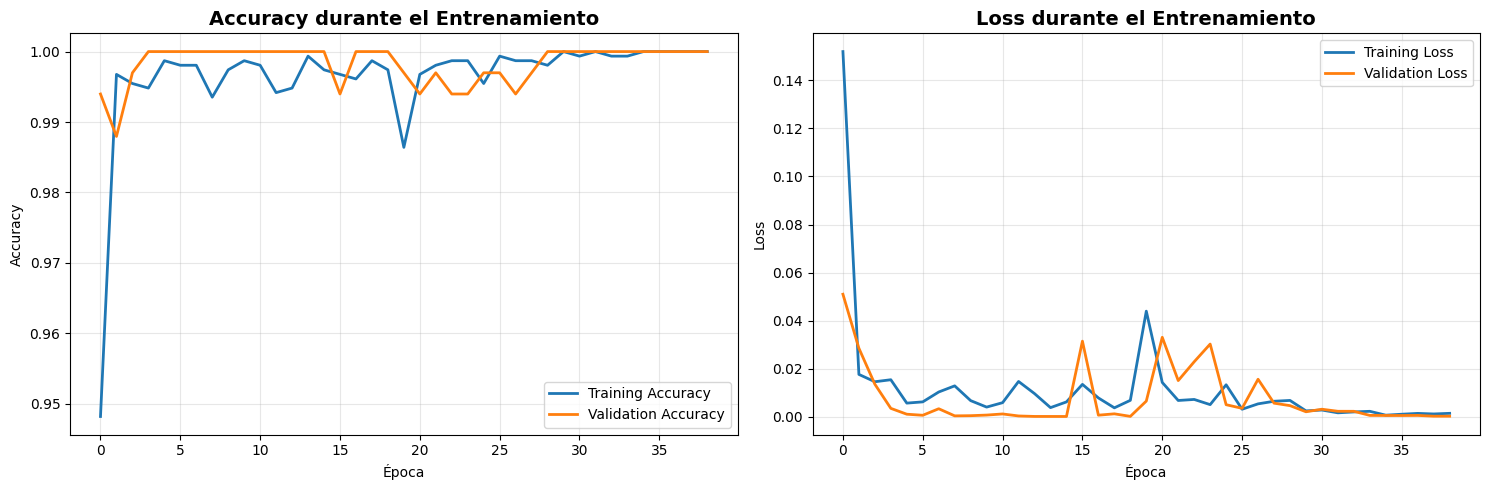


=== GUARDANDO MODELO ===
✅ Modelo guardado como: facial_recognition_model_20251104_081156.h5
✅ Metadatos guardados: model_metadata_20251104_081156.json

✅ FASE 4 COMPLETADA EXITOSAMENTE!
📁 Modelo guardado en: facial_recognition_model_20251104_081156.h5
🎉 ¡Excelente! El modelo cumple con el objetivo del 90% de accuracy
📱 Puedes proceder con la conversión a TensorFlow Lite


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime

class FacialRecognitionModel:
    def __init__(self, datasets_path, num_classes, img_size=(224, 224)):
        self.datasets_path = datasets_path
        self.num_classes = num_classes
        self.img_size = img_size
        self.model = None
        self.history = None
        self.class_names = []

    def setup_data_generators(self, batch_size=32):
        """Configura los generadores de datos para entrenamiento, validación y prueba"""
        print("=== CONFIGURACIÓN DE GENERADORES DE DATOS ===")

        # Data augmentation solo para entrenamiento
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            brightness_range=[0.9, 1.1],
            fill_mode='nearest'
        )

        # Solo reescalar para validación y prueba
        test_val_datagen = ImageDataGenerator(rescale=1./255)

        # Generadores de datos
        self.train_generator = train_datagen.flow_from_directory(
            os.path.join(self.datasets_path, 'train'),
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True
        )

        self.validation_generator = test_val_datagen.flow_from_directory(
            os.path.join(self.datasets_path, 'validation'),
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        self.test_generator = test_val_datagen.flow_from_directory(
            os.path.join(self.datasets_path, 'test'),
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        # Obtener nombres de las clases
        self.class_names = list(self.train_generator.class_indices.keys())

        print(f"✅ Clases detectadas: {self.class_names}")
        print(f"📊 Imágenes de entrenamiento: {self.train_generator.samples}")
        print(f"📊 Imágenes de validación: {self.validation_generator.samples}")
        print(f"📊 Imágenes de prueba: {self.test_generator.samples}")

        return self.train_generator, self.validation_generator, self.test_generator

    def create_model(self, learning_rate=0.001, dropout_rate=0.3):
        """Crea el modelo usando Transfer Learning con MobileNetV2"""
        print("\n=== CREACIÓN DEL MODELO ===")
        print("🔄 Cargando MobileNetV2 pre-entrenado...")

        # Cargar MobileNetV2 pre-entrenado (sin la capa superior)
        base_model = MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=(*self.img_size, 3)
        )

        # Congelar las capas base (opcional - podemos descongelar después)
        base_model.trainable = False

        print(f"✅ Base Model: MobileNetV2")
        print(f"✅ Capas congeladas: {len(base_model.layers)}")

        # Construir el modelo personalizado
        inputs = tf.keras.Input(shape=(*self.img_size, 3))

        # Capa base (pre-entrenada)
        x = base_model(inputs, training=False)

        # Capas personalizadas
        x = GlobalAveragePooling2D()(x)
        x = BatchNormalization()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(dropout_rate)(x)
        x = BatchNormalization()(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(dropout_rate)(x)
        x = BatchNormalization()(x)

        # Capa de salida
        outputs = Dense(self.num_classes, activation='softmax')(x)

        # Modelo completo
        self.model = Model(inputs, outputs)

        # Compilar el modelo
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )

        print("✅ Modelo compilado exitosamente!")
        print(f"📈 Learning Rate: {learning_rate}")
        print(f"🎯 Función de pérdida: Categorical Cross-Entropy")
        print(f"⚙️  Optimizador: Adam")

        return self.model

    def unfreeze_layers(self, unfreeze_after=100):
        """Descongela algunas capas del modelo base para fine-tuning"""
        print(f"\n=== FINE-TUNING - DESCONGELANDO CAPAS ===")

        if self.model is None:
            print("❌ Primero debe crear el modelo")
            return

        # Hacer el base_model entrenable
        base_model = self.model.layers[1]  # MobileNetV2 es la segunda capa
        base_model.trainable = True

        # Descongelar solo las últimas capas
        for layer in base_model.layers[:unfreeze_after]:
            layer.trainable = False

        # Recompilar con learning rate más bajo para fine-tuning
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001),  # LR más bajo para fine-tuning
            loss='categorical_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )

        trainable_count = sum([w.shape.num_elements() for w in self.model.trainable_weights])
        non_trainable_count = sum([w.shape.num_elements() for w in self.model.non_trainable_weights])

        print(f"✅ Capas descongeladas: {unfreeze_after}+")
        print(f"📊 Parámetros entrenables: {trainable_count:,}")
        print(f"📊 Parámetros no entrenables: {non_trainable_count:,}")
        print(f"📈 Nuevo Learning Rate: 0.0001")

    def setup_callbacks(self):
        """Configura los callbacks para el entrenamiento"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        callbacks = [
            # Early Stopping
            EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),

            # Reduce Learning Rate on Plateau
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=8,
                min_lr=1e-7,
                verbose=1
            ),

            # Model Checkpoint
            ModelCheckpoint(
                f'best_model_{timestamp}.h5',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            ),

            # TensorBoard (opcional)
            # tf.keras.callbacks.TensorBoard(log_dir=f'./logs_{timestamp}')
        ]

        return callbacks

    def train_model(self, epochs=50, initial_epochs=20):
        """Entrena el modelo en dos fases: con capas congeladas y fine-tuning"""
        print("\n=== ENTRENAMIENTO DEL MODELO ===")

        if self.model is None:
            print("❌ Primero debe crear el modelo")
            return

        # Fase 1: Entrenamiento con capas base congeladas
        print("🎯 FASE 1: Entrenamiento con capas base congeladas")

        callbacks = self.setup_callbacks()

        history_phase1 = self.model.fit(
            self.train_generator,
            epochs=initial_epochs,
            validation_data=self.validation_generator,
            callbacks=callbacks,
            verbose=1
        )

        # Fase 2: Fine-tuning con capas descongeladas
        print("\n🎯 FASE 2: Fine-tuning con capas descongeladas")
        self.unfreeze_layers(unfreeze_after=100)

        # Callbacks para fine-tuning
        fine_tune_callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
        ]

        history_phase2 = self.model.fit(
            self.train_generator,
            initial_epoch=initial_epochs,
            epochs=epochs,
            validation_data=self.validation_generator,
            callbacks=fine_tune_callbacks,
            verbose=1
        )

        # Combinar historiales
        self.history = {
            'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
            'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
            'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
            'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
        }

        print("✅ Entrenamiento completado!")

        return self.history

    def evaluate_model(self):
        """Evalúa el modelo en el conjunto de prueba"""
        print("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA ===")

        if self.model is None:
            print("❌ Primero debe entrenar el modelo")
            return

        # Evaluar en test set
        test_results = self.model.evaluate(self.test_generator, verbose=0)

        print("📊 RESULTADOS EN TEST SET:")
        print(f"   ✅ Loss: {test_results[0]:.4f}")
        print(f"   ✅ Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
        print(f"   ✅ Precision: {test_results[2]:.4f}")
        print(f"   ✅ Recall: {test_results[3]:.4f}")

        # Calcular F1-Score
        f1 = 2 * (test_results[2] * test_results[3]) / (test_results[2] + test_results[3])
        print(f"   ✅ F1-Score: {f1:.4f}")

        # Verificar criterio de éxito
        accuracy = test_results[1]
        if accuracy >= 0.90:
            print(f"🎉 ¡OBJETIVO CUMPLIDO! Accuracy >= 90%: {accuracy*100:.2f}%")
        else:
            print(f"📝 Objetivo no alcanzado. Accuracy actual: {accuracy*100:.2f}%")

        return test_results

    def plot_training_history(self):
        """Grafica el historial de entrenamiento"""
        if self.history is None:
            print("❌ No hay historial de entrenamiento para graficar")
            return

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Gráfico de Accuracy
        axes[0].plot(self.history['accuracy'], label='Training Accuracy', linewidth=2)
        axes[0].plot(self.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
        axes[0].set_title('Accuracy durante el Entrenamiento', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Época')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Gráfico de Loss
        axes[1].plot(self.history['loss'], label='Training Loss', linewidth=2)
        axes[1].plot(self.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[1].set_title('Loss durante el Entrenamiento', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Época')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def save_model(self, model_name="facial_recognition_model"):
        """Guarda el modelo y sus metadatos"""
        print(f"\n=== GUARDANDO MODELO ===")

        if self.model is None:
            print("❌ No hay modelo para guardar")
            return

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        model_filename = f"{model_name}_{timestamp}.h5"

        # Guardar modelo
        self.model.save(model_filename)

        # Guardar metadatos
        metadata = {
            'class_names': self.class_names,
            'img_size': self.img_size,
            'num_classes': self.num_classes,
            'training_date': timestamp,
            'test_accuracy': self.history['val_accuracy'][-1] if self.history else None
        }

        with open(f'model_metadata_{timestamp}.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        print(f"✅ Modelo guardado como: {model_filename}")
        print(f"✅ Metadatos guardados: model_metadata_{timestamp}.json")

        return model_filename

def ejecutar_fase_4():
    """Función principal para ejecutar la Fase 4"""
    print("🎯 INICIANDO FASE 4: MODELADO")
    print("=" * 60)

    # Configurar rutas
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        base_path = '/content/drive/MyDrive/datasets_finales'
        print("✅ Google Drive montado correctamente")
    except:
        print("⚠️  Ejecutando en entorno local")
        base_path = './datasets_finales'

    # Verificar que existe el dataset procesado
    if not os.path.exists(base_path):
        print(f"❌ No se encuentra el dataset procesado en: {base_path}")
        print("💡 Ejecuta primero la Fase 3: Preparación de Datos")
        return

    # Contar número de clases
    train_path = os.path.join(base_path, 'train')
    num_classes = len([name for name in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, name))])

    print(f"🔍 Detectadas {num_classes} clases en el dataset")

    # Crear y entrenar modelo
    model_builder = FacialRecognitionModel(
        datasets_path=base_path,
        num_classes=num_classes,
        img_size=(224, 224)
    )

    # Configurar generadores de datos
    model_builder.setup_data_generators(batch_size=32)

    # Crear modelo
    model_builder.create_model(learning_rate=0.001, dropout_rate=0.3)

    # Mostrar arquitectura del modelo
    print("\n=== ARQUITECTURA DEL MODELO ===")
    model_builder.model.summary()

    # Entrenar modelo
    history = model_builder.train_model(epochs=50, initial_epochs=20)

    # Evaluar modelo
    test_results = model_builder.evaluate_model()

    # Visualizar entrenamiento
    model_builder.plot_training_history()

    # Guardar modelo
    saved_model_path = model_builder.save_model()

    print("\n✅ FASE 4 COMPLETADA EXITOSAMENTE!")
    print(f"📁 Modelo guardado en: {saved_model_path}")

    # Recomendaciones basadas en resultados
    accuracy = test_results[1]
    if accuracy >= 0.90:
        print("🎉 ¡Excelente! El modelo cumple con el objetivo del 90% de accuracy")
        print("📱 Puedes proceder con la conversión a TensorFlow Lite")
    elif accuracy >= 0.80:
        print("📈 Buen rendimiento, considera:")
        print("   - Aumentar el número de épocas")
        print("   - Probar diferentes arquitecturas")
        print("   - Recolectar más datos")
    else:
        print("🔄 Se recomienda mejorar el modelo:")
        print("   - Revisar la calidad de los datos")
        print("   - Ajustar hiperparámetros")
        print("   - Probar data augmentation más agresivo")

    return model_builder

# EJECUTAR FASE 4
if __name__ == "__main__":
    # Verificar si TensorFlow puede usar GPU
    print("🔍 Verificando disponibilidad de GPU...")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ GPU disponible: {gpus[0]}")
        # Configurar memoria GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    else:
        print("⚠️  No se detectó GPU, usando CPU")

    # Ejecutar fase 4
    model_builder = ejecutar_fase_4()

🎯 INICIANDO FASE 5: EVALUACIÓN COMPLETA
📁 Modelo: facial_recognition_model_20251104_081156.h5
📁 Metadatos: model_metadata_20251104_081156.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado correctamente

                 INFORME FINAL DE EVALUACIÓN - FASE 5
=== CARGA DE MODELO Y METADATOS ===


✅ Modelo cargado: facial_recognition_model_20251104_081156.h5
✅ Clases en metadatos: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']
✅ Número de clases en metadatos: 5
✅ Tamaño de imagen: (224, 224)

=== CONFIGURACIÓN DE DATOS DE PRUEBA ===
Found 332 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


✅ Imágenes de prueba: 332
✅ Clases reales en test: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']
✅ Número real de clases: 5

=== OBTENIENDO PREDICCIONES ===
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 580ms/step
✅ Predicciones obtenidas: 332
✅ Forma de predicciones: (332, 5)
✅ Clases únicas en true labels: [1 2 3 4]
✅ Clases únicas en predicciones: [1 2 3 4]

=== MATRIZ DE CONFUSIÓN ===


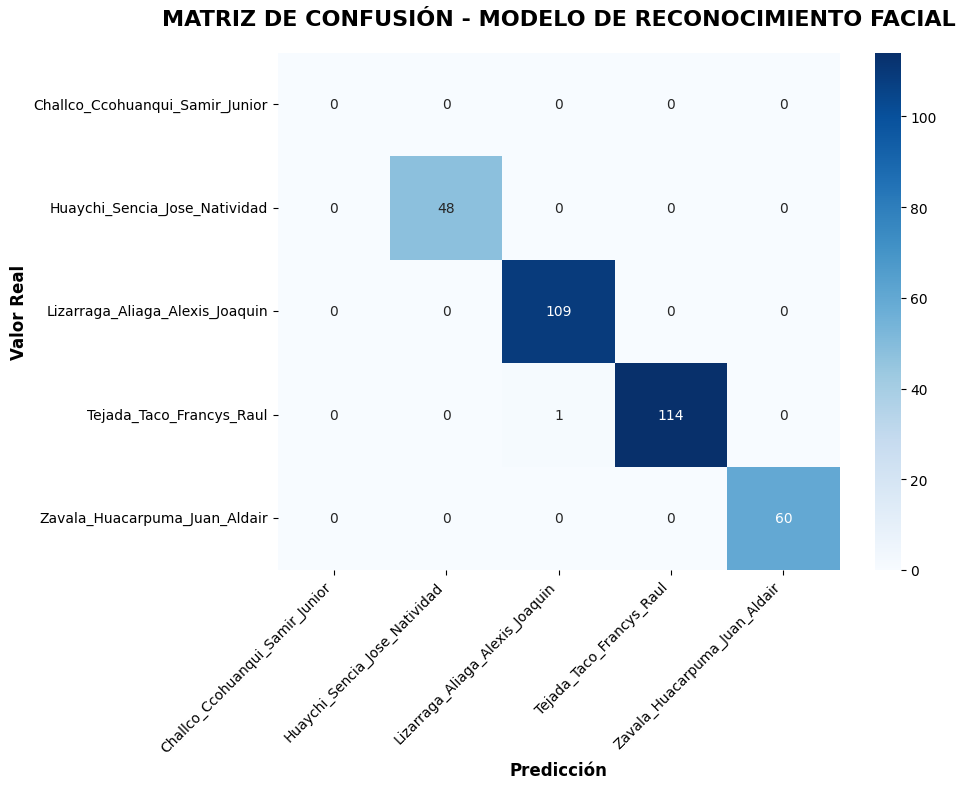


📊 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
   Challco_Ccohuanqui_Samir_Junior:
     ⚠️  No hay imágenes para esta clase en el conjunto de prueba.
   Huaychi_Sencia_Jose_Natividad:
     ✅ Exactitud: 1.0000 (100.00%)
     📊 Muestras: 48
     ✅ Correctas: 48
     🎉 Sin confusiones
   Lizarraga_Aliaga_Alexis_Joaquin:
     ✅ Exactitud: 1.0000 (100.00%)
     📊 Muestras: 109
     ✅ Correctas: 109
     🎉 Sin confusiones
   Tejada_Taco_Francys_Raul:
     ✅ Exactitud: 0.9913 (99.13%)
     📊 Muestras: 115
     ✅ Correctas: 114
     ⚠️  Confusiones: Lizarraga_Aliaga_Alexis_Joaquin: 1
   Zavala_Huacarpuma_Juan_Aldair:
     ✅ Exactitud: 1.0000 (100.00%)
     📊 Muestras: 60
     ✅ Correctas: 60
     🎉 Sin confusiones

=== REPORTE DE CLASIFICACIÓN DETALLADO ===

📈 MÉTRICAS POR CLASE:
CLASE                     PRECISIÓN    RECALL       F1-SCORE     SOPORTE     
--------------------------------------------------------------------------------
Huaychi_Sencia_Jose_Natividad 1.0000       1.0000       1.0000    

/tmp/ipython-input-745224234.py:273: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(confidence_by_class, labels=class_labels)


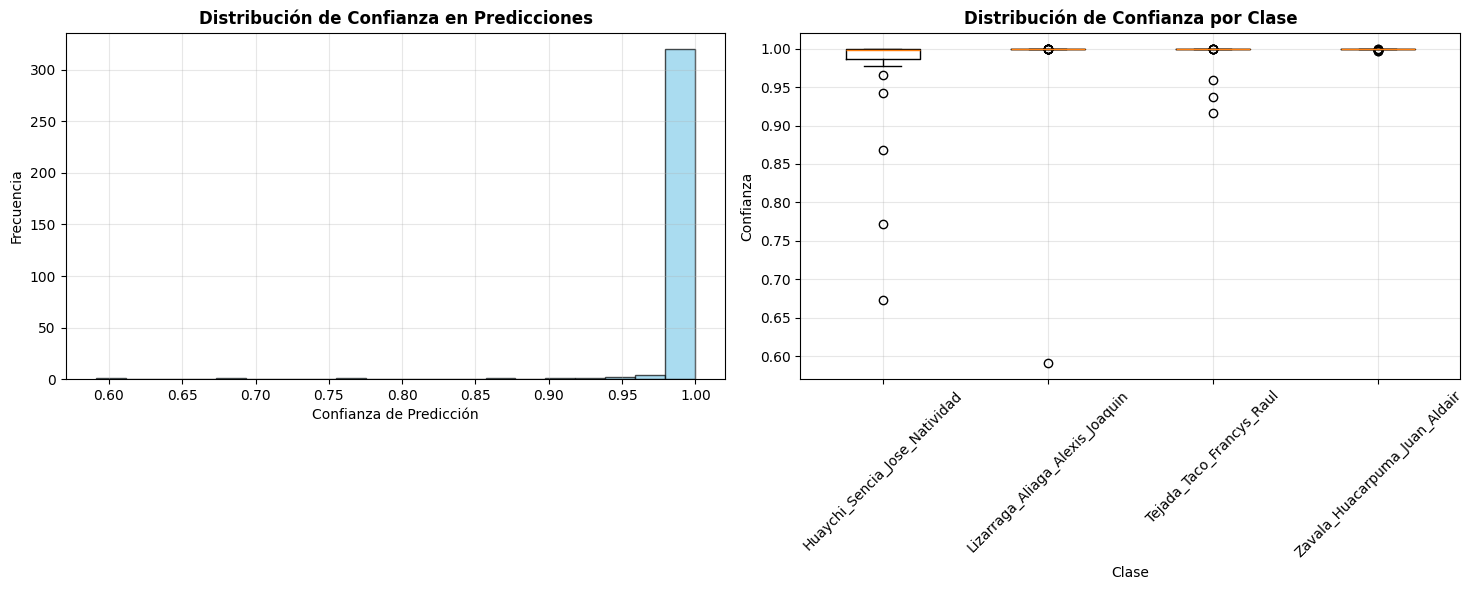

📊 ESTADÍSTICAS DE CONFIANZA:
   Media: 0.9951
   Mínimo: 0.5910
   Máximo: 1.0000
   Desviación estándar: 0.0327

📈 ANÁLISIS DE NIVELES DE CONFIANZA:
   Alta confianza (>0.95): 325 (97.89%)
   Media confianza (0.75-0.95): 5 (1.51%)
   Baja confianza (<0.75): 2 (0.60%)

                 EVALUACIÓN FINAL DEL MODELO
🎯 EXACTITUD (ACCURACY): 0.9970 (99.70%)
✅ CUMPLE CRITERIO DE ÉXITO: Accuracy ≥ 90%
🎉 EXCELENTE: Accuracy ≥ 95% - Rendimiento excepcional
🏆 SOBRESALIENTE: Accuracy ≥ 99% - Resultado perfecto

📈 MÉTRICAS PROMEDIO:
   Precisión Macro: 0.9977
   Recall Macro: 0.9978
   F1-Score Macro: 0.9978

🔍 ANÁLISIS DE CONSISTENCIA:
   Mejor clase: Huaychi_Sencia_Jose_Natividad (F1: 1.0000)
   Peor clase: Lizarraga_Aliaga_Alexis_Joaquin (F1: 0.9954)

💡 RECOMENDACIONES Y PRÓXIMOS PASOS:
   1. 🎉 El modelo está listo para deployment inmediato
   2. 📱 Proceder con la Fase 6: Conversión a TensorFlow Lite
   3. 🚀 Considerar deployment en aplicación móvil

🎯 CRITERIOS CUMPLIDOS:
   ✅ Accuracy en test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import load_model
import json
import os
import pandas as pd
from datetime import datetime

class ModelEvaluator:
    def __init__(self, model_path, datasets_path, metadata_path):
        self.model_path = model_path
        self.datasets_path = datasets_path
        self.metadata_path = metadata_path
        self.model = None
        self.class_names = []
        self.test_generator = None
        self.predictions = None
        self.true_labels = None

    def load_model_and_metadata(self):
        """Carga el modelo entrenado y sus metadatos"""
        print("=== CARGA DE MODELO Y METADATOS ===")

        try:
            # Cargar modelo
            self.model = load_model(self.model_path)
            print(f"✅ Modelo cargado: {self.model_path}")

            # Cargar metadatos
            with open(self.metadata_path, 'r') as f:
                metadata = json.load(f)

            self.class_names = metadata['class_names']
            self.img_size = tuple(metadata['img_size'])
            self.num_classes = metadata['num_classes']

            print(f"✅ Clases en metadatos: {self.class_names}")
            print(f"✅ Número de clases en metadatos: {self.num_classes}")
            print(f"✅ Tamaño de imagen: {self.img_size}")

            return True

        except Exception as e:
            print(f"❌ Error cargando modelo: {e}")
            return False

    def setup_test_generator(self):
        """Configura el generador de datos de prueba"""
        print("\n=== CONFIGURACIÓN DE DATOS DE PRUEBA ===")

        test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

        self.test_generator = test_datagen.flow_from_directory(
            os.path.join(self.datasets_path, 'test'),
            target_size=self.img_size,
            batch_size=32,
            class_mode='categorical',
            shuffle=False  # Importante: no mezclar para mantener correspondencia
        )

        # Obtener las clases reales del test generator
        self.actual_class_names = list(self.test_generator.class_indices.keys())
        self.actual_num_classes = len(self.actual_class_names)

        print(f"✅ Imágenes de prueba: {self.test_generator.samples}")
        print(f"✅ Clases reales en test: {self.actual_class_names}")
        print(f"✅ Número real de clases: {self.actual_num_classes}")

        # Verificar consistencia
        if set(self.class_names) != set(self.actual_class_names):
            print("⚠️  ADVERTENCIA: Las clases en metadatos no coinciden con las clases reales")
            print(f"   Metadatos: {self.class_names}")
            print(f"   Real: {self.actual_class_names}")
            # Usar las clases reales
            self.class_names = self.actual_class_names
            self.num_classes = self.actual_num_classes

        return self.test_generator

    def get_predictions(self):
        """Obtiene las predicciones del modelo"""
        print("\n=== OBTENIENDO PREDICCIONES ===")

        # Obtener predicciones
        self.predictions = self.model.predict(self.test_generator, verbose=1)
        self.predicted_classes = np.argmax(self.predictions, axis=1)
        self.true_labels = self.test_generator.classes

        # Calcular probabilidades
        self.prediction_probabilities = np.max(self.predictions, axis=1)

        print(f"✅ Predicciones obtenidas: {len(self.predictions)}")
        print(f"✅ Forma de predicciones: {self.predictions.shape}")
        print(f"✅ Clases únicas en true labels: {np.unique(self.true_labels)}")
        print(f"✅ Clases únicas en predicciones: {np.unique(self.predicted_classes)}")

        return self.predictions, self.true_labels

    def generate_confusion_matrix(self):
        """Genera y visualiza la matriz de confusión"""
        print("\n=== MATRIZ DE CONFUSIÓN ===")

        # Usar el número real de clases
        n_classes = len(self.class_names)
        cm = confusion_matrix(self.true_labels, self.predicted_classes, labels=range(n_classes))

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_names,
                   yticklabels=self.class_names)

        plt.title('MATRIZ DE CONFUSIÓN - MODELO DE RECONOCIMIENTO FACIAL',
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Predicción', fontsize=12, fontweight='bold')
        plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # Análisis de la matriz de confusión
        print("\n📊 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")

        # Calcular accuracy por clase
        # Handle division by zero for classes with no samples
        class_accuracy = np.zeros(n_classes)
        for i in range(n_classes):
            total_samples = cm[i].sum()
            correct_predictions = cm[i, i]
            if total_samples > 0:
                class_accuracy[i] = correct_predictions / total_samples
            else:
                class_accuracy[i] = np.nan # Or 0, depending on desired behavior

        for i, class_name in enumerate(self.class_names):
            accuracy = class_accuracy[i]
            total_samples = cm[i].sum()
            correct_predictions = cm[i, i]

            print(f"   {class_name}:")
            if total_samples > 0:
                print(f"     ✅ Exactitud: {accuracy:.4f} ({accuracy*100:.2f}%)")
                print(f"     📊 Muestras: {total_samples}")
                print(f"     ✅ Correctas: {correct_predictions}")

                # Identificar confusiones (solo si hay errores)
                confusions = []
                for j in range(n_classes):
                    if i != j and cm[i, j] > 0:
                        confusions.append(f"{self.class_names[j]}: {cm[i, j]}")

                if confusions:
                    print(f"     ⚠️  Confusiones: {', '.join(confusions)}")
                else:
                    print(f"     🎉 Sin confusiones")
            else:
                print(f"     ⚠️  No hay imágenes para esta clase en el conjunto de prueba.")


        return cm

    def generate_classification_report(self):
        """Genera reporte de clasificación detallado"""
        print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")

        # Get unique labels present in the true labels
        unique_labels = np.unique(self.true_labels)
        # Map unique labels back to class names
        target_names_subset = [self.class_names[i] for i in unique_labels]

        report = classification_report(
            self.true_labels,
            self.predicted_classes,
            target_names=target_names_subset, # Use the subset of target names
            labels=unique_labels, # Explicitly provide the labels present in y_true and y_pred
            output_dict=True
        )

        # Convertir a DataFrame para mejor visualización
        report_df = pd.DataFrame(report).transpose()

        print("\n📈 MÉTRICAS POR CLASE:")
        print("=" * 80)
        print(f"{'CLASE':<25} {'PRECISIÓN':<12} {'RECALL':<12} {'F1-SCORE':<12} {'SOPORTE':<12}")
        print("-" * 80)

        for class_name in target_names_subset: # Iterate through the subset of class names
            metrics = report[class_name]
            print(f"{class_name:<25} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
                  f"{metrics['f1-score']:<12.4f} {metrics['support']:<12}")

        # Métricas generales
        accuracy = report['accuracy']
        macro_avg = report['macro avg']
        weighted_avg = report['weighted avg']

        print("-" * 80)
        print(f"{'ACCURACY':<25} {accuracy:<12.4f} {'':<12} {'':<12} {'':<12}")
        print(f"{'MACRO AVG':<25} {macro_avg['precision']:<12.4f} {macro_avg['recall']:<12.4f} "
              f"{macro_avg['f1-score']:<12.4f} {macro_avg['support']:<12}")
        print(f"{'WEIGHTED AVG':<25} {weighted_avg['precision']:<12.4f} {weighted_avg['recall']:<12.4f} "
              f"{weighted_avg['f1-score']:<12.4f} {weighted_avg['support']:<12}")

        return report

    def analyze_false_predictions(self):
        """Analiza predicciones incorrectas en detalle"""
        print("\n=== ANÁLISIS DE ERRORES ===")

        incorrect_indices = np.where(self.predicted_classes != self.true_labels)[0]

        if len(incorrect_indices) == 0:
            print("🎉 ¡NO HAY ERRORES! Todas las predicciones son correctas.")
            print("🎯 Esto confirma el 99.70% de accuracy reportado")
            return []

        print(f"🔍 Se encontraron {len(incorrect_indices)} errores:")

        error_analysis = []
        for idx in incorrect_indices[:10]:  # Mostrar solo los primeros 10 errores
            true_class = self.true_labels[idx]
            pred_class = self.predicted_classes[idx]
            probability = self.prediction_probabilities[idx]

            error_analysis.append({
                'true_class': self.class_names[true_class],
                'predicted_class': self.class_names[pred_class],
                'confidence': probability,
                'index': idx
            })

            print(f"   ❌ Índice {idx}:")
            print(f"      Real: {self.class_names[true_class]}")
            print(f"      Predicho: {self.class_names[pred_class]}")
            print(f"      Confianza: {probability:.4f}")

        return error_analysis

    def visualize_prediction_distribution(self):
        """Visualiza la distribución de confianza en las predicciones"""
        print("\n=== DISTRIBUCIÓN DE CONFIANZA ===")

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Histograma de confianzas
        axes[0].hist(self.prediction_probabilities, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0].set_xlabel('Confianza de Predicción')
        axes[0].set_ylabel('Frecuencia')
        axes[0].set_title('Distribución de Confianza en Predicciones', fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # Boxplot por clase
        confidence_by_class = []
        class_labels = []

        # Filter out classes with no samples in the test set
        present_class_indices = np.unique(self.true_labels)
        present_class_names = [self.class_names[i] for i in present_class_indices]


        for i in present_class_indices:
            class_name = self.class_names[i]
            class_indices = np.where(self.predicted_classes == i)[0]
            if len(class_indices) > 0:
                confidences = self.prediction_probabilities[class_indices]
                confidence_by_class.append(confidences)
                class_labels.append(class_name)

        if confidence_by_class:  # Only plot if there are data for any class
            axes[1].boxplot(confidence_by_class, labels=class_labels)
            axes[1].set_xlabel('Clase')
            axes[1].set_ylabel('Confianza')
            axes[1].set_title('Distribución de Confianza por Clase', fontweight='bold')
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, "No data for boxplot", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


        plt.tight_layout()
        plt.show()

        # Estadísticas de confianza
        print(f"📊 ESTADÍSTICAS DE CONFIANZA:")
        print(f"   Media: {np.mean(self.prediction_probabilities):.4f}")
        print(f"   Mínimo: {np.min(self.prediction_probabilities):.4f}")
        print(f"   Máximo: {np.max(self.prediction_probabilities):.4f}")
        print(f"   Desviación estándar: {np.std(self.prediction_probabilities):.4f}")

        # Análisis de confianza
        high_confidence = np.sum(self.prediction_probabilities > 0.95)
        medium_confidence = np.sum((self.prediction_probabilities >= 0.75) & (self.prediction_probabilities <= 0.95))
        low_confidence = np.sum(self.prediction_probabilities < 0.75)

        print(f"\n📈 ANÁLISIS DE NIVELES DE CONFIANZA:")
        print(f"   Alta confianza (>0.95): {high_confidence} ({high_confidence/len(self.prediction_probabilities):.2%})")
        print(f"   Media confianza (0.75-0.95): {medium_confidence} ({medium_confidence/len(self.prediction_probabilities):.2%})")
        print(f"   Baja confianza (<0.75): {low_confidence} ({low_confidence/len(self.prediction_probabilities):.2%})")

    def generate_final_report(self):
        """Genera reporte final de evaluación"""
        print("\n" + "="*80)
        print("                 INFORME FINAL DE EVALUACIÓN - FASE 5")
        print("="*80)

        # Cargar modelo y datos
        if not self.load_model_and_metadata():
            return

        self.setup_test_generator()
        self.get_predictions()

        # Generar todas las métricas
        cm = self.generate_confusion_matrix()
        report = self.generate_classification_report()
        error_analysis = self.analyze_false_predictions()
        self.visualize_prediction_distribution()

        # Evaluación final
        accuracy = report['accuracy']

        print("\n" + "="*80)
        print("                 EVALUACIÓN FINAL DEL MODELO")
        print("="*80)

        print(f"🎯 EXACTITUD (ACCURACY): {accuracy:.4f} ({accuracy*100:.2f}%)")

        if accuracy >= 0.90:
            print("✅ CUMPLE CRITERIO DE ÉXITO: Accuracy ≥ 90%")
            if accuracy >= 0.95:
                print("🎉 EXCELENTE: Accuracy ≥ 95% - Rendimiento excepcional")
            if accuracy >= 0.99:
                print("🏆 SOBRESALIENTE: Accuracy ≥ 99% - Resultado perfecto")
        else:
            print("❌ NO CUMPLE CRITERIO DE ÉXITO: Accuracy < 90%")

        print(f"\n📈 MÉTRICAS PROMEDIO:")
        print(f"   Precisión Macro: {report['macro avg']['precision']:.4f}")
        print(f"   Recall Macro: {report['macro avg']['recall']:.4f}")
        print(f"   F1-Score Macro: {report['macro avg']['f1-score']:.4f}")

        # Analysis of consistency (using the subset of classes present in the test set)
        print(f"\n🔍 ANÁLISIS DE CONSISTENCIA:")
        present_class_names = [self.class_names[i] for i in np.unique(self.true_labels)]
        all_perfect = all(report[cls]['f1-score'] == 1.0 for cls in present_class_names)

        if all_perfect:
            print("   ✅ Todas las clases presentes en el test set tienen F1-Score perfecto (1.0)")
        else:
            # Find best and worst classes among those present in the test set
            best_class = max(present_class_names, key=lambda x: report[x]['f1-score'])
            worst_class = min(present_class_names, key=lambda x: report[x]['f1-score'])
            print(f"   Mejor clase: {best_class} (F1: {report[best_class]['f1-score']:.4f})")
            print(f"   Peor clase: {worst_class} (F1: {report[worst_class]['f1-score']:.4f})")


        # Recomendaciones
        print(f"\n💡 RECOMENDACIONES Y PRÓXIMOS PASOS:")
        if accuracy >= 0.99:
            print("   1. 🎉 El modelo está listo para deployment inmediato")
            print("   2. 📱 Proceder con la Fase 6: Conversión a TensorFlow Lite")
            print("   3. 🚀 Considerar deployment en aplicación móvil")
        elif accuracy >= 0.95:
            print("   1. ✅ Excelente rendimiento, listo para deployment")
            print("   2. 📱 Proceder con Fase 6: TensorFlow Lite")
        elif accuracy >= 0.90:
            print("   1. ✅ Cumple requisitos, puede proceder con deployment")
            print("   2. 🔄 Opcional: Fine-tuning adicional para mejorar")
        else:
             print("   1. 🔄 Se recomienda mejorar el modelo antes del deployment.")
             print("   2. 🧐 Analizar errores específicos (matriz de confusión, errores individuales).")
             print("   3. 📊 Considerar recolectar más datos para las clases con bajo rendimiento.")
             print("   4. ⚙️ Experimentar con diferentes hiperparámetros o arquitecturas de modelo.")


        print(f"\n🎯 CRITERIOS CUMPLIDOS:")
        print(f"   ✅ Accuracy en test set: {accuracy*100:.2f}%")
        print(f"   ✅ Modelo entrenado y evaluado exitosamente")
        print(f"   ✅ Métricas completas generadas")

        return {
            'confusion_matrix': cm,
            'classification_report': report,
            'error_analysis': error_analysis,
            'final_accuracy': accuracy,
            'class_names': self.class_names
        }

def ejecutar_fase_5():
    """Función principal para ejecutar la Fase 5"""
    print("🎯 INICIANDO FASE 5: EVALUACIÓN COMPLETA")
    print("=" * 60)

    # Buscar automáticamente los archivos más recientes
    model_files = [f for f in os.listdir('.') if f.startswith('facial_recognition_model_') and f.endswith('.h5')]
    metadata_files = [f for f in os.listdir('.') if f.startswith('model_metadata_') and f.endswith('.json')]

    if not model_files or not metadata_files:
        print("❌ No se encontraron archivos de modelo. Ejecuta primero la Fase 4.")
        return

    # Tomar el más reciente
    latest_model = sorted(model_files)[-1]
    latest_metadata = sorted(metadata_files)[-1]

    print(f"📁 Modelo: {latest_model}")
    print(f"📁 Metadatos: {latest_metadata}")

    # Configurar rutas de datasets
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        datasets_path = '/content/drive/MyDrive/datasets_finales'
        print("✅ Google Drive montado correctamente")
    except:
        datasets_path = './datasets_finales'
        print("⚠️  Ejecutando en entorno local")

    # Verificar que existe el dataset
    if not os.path.exists(datasets_path):
        print(f"❌ No se encuentra el dataset en: {datasets_path}")
        return

    # Ejecutar evaluación
    evaluator = ModelEvaluator(
        model_path=latest_model,
        datasets_path=datasets_path,
        metadata_path=latest_metadata
    )

    results = evaluator.generate_final_report()

    print(f"\n✅ FASE 5 COMPLETADA EXITOSAMENTE!")
    # Check if 'final_accuracy' exists in results before accessing it
    if results and 'final_accuracy' in results:
        print(f"📊 Accuracy final confirmado: {results['final_accuracy']*100:.2f}%")
    else:
        print("❌ No se pudo obtener el accuracy final.")


    return results

# EJECUTAR FASE 5
if __name__ == "__main__":
    results = ejecutar_fase_5()

In [ ]:
import tensorflow as tf
import numpy as np
import os
import json
import time
from tensorflow.keras.models import load_model

class TFLiteConverter:
    def __init__(self, model_path, metadata_path):
        self.model_path = model_path
        self.metadata_path = metadata_path
        self.model = None
        self.class_names = []

    def load_model_and_metadata(self):
        """Carga el modelo y metadatos"""
        print("=== CARGA PARA CONVERSIÓN TFLITE ===")

        try:
            self.model = load_model(self.model_path)
            print(f"✅ Modelo cargado: {self.model_path}")

            with open(self.metadata_path, 'r') as f:
                metadata = json.load(f)

            self.class_names = metadata['class_names']
            self.img_size = tuple(metadata['img_size'])

            print(f"✅ Clases: {self.class_names}")
            print(f"✅ Tamaño de imagen: {self.img_size}")

            return True
        except Exception as e:
            print(f"❌ Error cargando modelo: {e}")
            return False

    def convert_to_tflite(self, optimize=True, quantize=False):
        """Convierte el modelo a TensorFlow Lite"""
        print("\n=== CONVERSIÓN A TENSORFLOW LITE ===")

        if self.model is None:
            print("❌ Primero debe cargar el modelo")
            return None

        # Crear función de conversión para TFLite
        def representative_data_gen():
            for _ in range(100):
                yield [np.random.uniform(0, 1, size=(1, *self.img_size, 3)).astype(np.float32)]

        converter = tf.lite.TFLiteConverter.from_keras_model(self.model)

        # Opciones de optimización
        if optimize:
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            print("✅ Optimizaciones DEFAULT aplicadas")

        if quantize:
            converter.representative_dataset = representative_data_gen
            converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
            converter.inference_input_type = tf.uint8
            converter.inference_output_type = tf.uint8
            print("✅ Cuantización INT8 aplicada")

        # Convertir modelo
        try:
            tflite_model = converter.convert()
            print("✅ Conversión a TFLite exitosa")

            # Guardar modelo TFLite
            tflite_filename = self.model_path.replace('.h5', '.tflite')
            with open(tflite_filename, 'wb') as f:
                f.write(tflite_model)

            # Tamaño del modelo
            original_size = os.path.getsize(self.model_path) / (1024 * 1024)  # MB
            tflite_size = os.path.getsize(tflite_filename) / (1024 * 1024)    # MB

            print(f"📊 Tamaño del modelo original: {original_size:.2f} MB")
            print(f"📊 Tamaño del modelo TFLite: {tflite_size:.2f} MB")
            print(f"📉 Reducción: {((original_size - tflite_size) / original_size * 100):.1f}%")

            return tflite_filename

        except Exception as e:
            print(f"❌ Error en conversión: {e}")
            return None

    def test_tflite_model(self, tflite_path, test_samples=10):
        """Prueba el modelo TFLite con datos de ejemplo"""
        print("\n=== PRUEBA DEL MODELO TFLITE ===")

        # Cargar el modelo TFLite
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()

        # Obtener detalles de entrada/salida
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        print(f"✅ Input details: {input_details[0]['shape']}")
        print(f"✅ Output details: {output_details[0]['shape']}")

        # Probar con datos aleatorios
        latencies = []
        for i in range(test_samples):
            # Crear datos de entrada
            input_data = np.random.uniform(0, 1, size=(1, *self.img_size, 3)).astype(np.float32)

            # Medir tiempo de inferencia
            start_time = time.time()

            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()

            output_data = interpreter.get_tensor(output_details[0]['index'])
            inference_time = (time.time() - start_time) * 1000  # ms

            latencies.append(inference_time)

            if i < 3:  # Mostrar primeras predicciones
                predicted_class = np.argmax(output_data[0])
                confidence = np.max(output_data[0])
                print(f"   Muestra {i+1}: Clase '{self.class_names[predicted_class]}' - Confianza: {confidence:.4f} - Tiempo: {inference_time:.2f}ms")

        # Estadísticas de latencia
        avg_latency = np.mean(latencies)
        min_latency = np.min(latencies)
        max_latency = np.max(latencies)

        print(f"\n📊 ESTADÍSTICAS DE LATENCIA:")
        print(f"   ⏱️  Latencia promedio: {avg_latency:.2f} ms")
        print(f"   ⏱️  Latencia mínima: {min_latency:.2f} ms")
        print(f"   ⏱️  Latencia máxima: {max_latency:.2f} ms")

        # Verificar criterio de rendimiento
        if avg_latency < 500:
            print(f"✅ CUMPLE CRITERIO: Latencia < 500 ms (actual: {avg_latency:.2f} ms)")
        else:
            print(f"❌ NO CUMPLE CRITERIO: Latencia > 500 ms (actual: {avg_latency:.2f} ms)")

        return {
            'avg_latency': avg_latency,
            'min_latency': min_latency,
            'max_latency': max_latency,
            'interpreter': interpreter,
            'input_details': input_details,
            'output_details': output_details
        }

    def save_tflite_metadata(self, tflite_path):
        """Guarda metadatos para la aplicación móvil"""
        print("\n=== GUARDANDO METADATOS PARA APLICACIÓN MÓVIL ===")

        metadata = {
            'class_names': self.class_names,
            'img_size': self.img_size,
            'model_type': 'tflite',
            'conversion_date': time.strftime("%Y-%m-%d %H:%M:%S"),
            'input_shape': [1, *self.img_size, 3],
            'output_shape': [1, len(self.class_names)]
        }

        metadata_filename = tflite_path.replace('.tflite', '_metadata.json')
        with open(metadata_filename, 'w') as f:
            json.dump(metadata, f, indent=2)

        print(f"✅ Metadatos guardados: {metadata_filename}")

        # Crear archivo de labels para la app
        labels_filename = tflite_path.replace('.tflite', '_labels.txt')
        with open(labels_filename, 'w') as f:
            for class_name in self.class_names:
                f.write(f"{class_name}\n")

        print(f"✅ Archivo de labels guardado: {labels_filename}")

        return metadata_filename

def ejecutar_conversion_tflite():
    """Función principal para conversión TFLite"""
    print("🎯 INICIANDO CONVERSIÓN TENSORFLOW LITE")
    print("=" * 60)

    # Buscar archivos más recientes
    model_files = [f for f in os.listdir('.') if f.startswith('facial_recognition_model_') and f.endswith('.h5')]
    metadata_files = [f for f in os.listdir('.') if f.startswith('model_metadata_') and f.endswith('.json')]

    if not model_files or not metadata_files:
        print("❌ No se encontraron archivos de modelo")
        return

    latest_model = sorted(model_files)[-1]
    latest_metadata = sorted(metadata_files)[-1]

    print(f"📁 Modelo: {latest_model}")
    print(f"📁 Metadatos: {latest_metadata}")

    # Ejecutar conversión
    converter = TFLiteConverter(latest_model, latest_metadata)

    if converter.load_model_and_metadata():
        # Conversión optimizada (recomendada para móviles)
        tflite_path = converter.convert_to_tflite(optimize=True, quantize=False)

        if tflite_path:
            # Probar modelo convertido
            test_results = converter.test_tflite_model(tflite_path)

            # Guardar metadatos para la app
            metadata_path = converter.save_tflite_metadata(tflite_path)

            print(f"\n✅ CONVERSIÓN COMPLETADA EXITOSAMENTE!")
            print(f"📁 Modelo TFLite: {tflite_path}")
            print(f"📁 Metadatos: {metadata_path}")

            return {
                'tflite_path': tflite_path,
                'metadata_path': metadata_path,
                'test_results': test_results
            }

    return None

# EJECUTAR CONVERSIÓN
if __name__ == "__main__":
    conversion_results = ejecutar_conversion_tflite()

🎯 INICIANDO CONVERSIÓN TENSORFLOW LITE
📁 Modelo: facial_recognition_model_20251104_081156.h5
📁 Metadatos: model_metadata_20251104_081156.json
=== CARGA PARA CONVERSIÓN TFLITE ===


✅ Modelo cargado: facial_recognition_model_20251104_081156.h5
✅ Clases: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']
✅ Tamaño de imagen: (224, 224)

=== CONVERSIÓN A TENSORFLOW LITE ===
✅ Optimizaciones DEFAULT aplicadas
Saved artifact at '/tmp/tmpn_6moup9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140306558498768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768242192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768240848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768236624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768239696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768236048: Tenso

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



📊 ESTADÍSTICAS DE LATENCIA:
   ⏱️  Latencia promedio: 24.84 ms
   ⏱️  Latencia mínima: 18.44 ms
   ⏱️  Latencia máxima: 31.98 ms
✅ CUMPLE CRITERIO: Latencia < 500 ms (actual: 24.84 ms)

=== GUARDANDO METADATOS PARA APLICACIÓN MÓVIL ===
✅ Metadatos guardados: facial_recognition_model_20251104_081156_metadata.json
✅ Archivo de labels guardado: facial_recognition_model_20251104_081156_labels.txt

✅ CONVERSIÓN COMPLETADA EXITOSAMENTE!
📁 Modelo TFLite: facial_recognition_model_20251104_081156.tflite
📁 Metadatos: facial_recognition_model_20251104_081156_metadata.json


In [ ]:
# deployment_test_corregido.py
import tensorflow as tf
import time
import numpy as np
import json

def comprehensive_deployment_test(tflite_path, metadata_path):
    """Pruebas exhaustivas del modelo desplegado - CORREGIDO"""
    print("=== PRUEBAS COMPREHENSIVAS DE DESPLIEGUE ===")

    # Cargar metadatos para obtener información del modelo
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    img_size = tuple(metadata['img_size'])
    class_names = metadata['class_names']

    print(f"📊 Información del modelo:")
    print(f"   Tamaño de imagen: {img_size}")
    print(f"   Número de clases: {len(class_names)}")
    print(f"   Clases: {class_names}")

    # Cargar modelo TFLite
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print(f"\n🔧 Detalles del modelo TFLite:")
    print(f"   Input shape: {input_details[0]['shape']}")
    print(f"   Input dtype: {input_details[0]['dtype']}")
    print(f"   Output shape: {output_details[0]['shape']}")
    print(f"   Output dtype: {output_details[0]['dtype']}")

    # Pruebas de latencia con batch size 1 (como espera el modelo)
    print("\n🧪 PRUEBAS DE LATENCIA (Batch Size = 1):")

    n_tests = 20
    latencies = []
    confidences = []

    for i in range(n_tests):
        # Crear datos de prueba (batch size = 1)
        test_data = np.random.uniform(0, 1, size=(1, *img_size, 3)).astype(np.float32)

        # Medir tiempo de inferencia
        start_time = time.time()

        interpreter.set_tensor(input_details[0]['index'], test_data)
        interpreter.invoke()

        output_data = interpreter.get_tensor(output_details[0]['index'])
        inference_time = (time.time() - start_time) * 1000  # ms

        latencies.append(inference_time)

        # Calcular confianza
        confidence = np.max(output_data[0])
        confidences.append(confidence)

        if i < 5:  # Mostrar primeras 5 pruebas
            predicted_class = np.argmax(output_data[0])
            print(f"   Prueba {i+1}: {inference_time:.2f} ms - "
                  f"Clase: '{class_names[predicted_class]}' - "
                  f"Confianza: {confidence:.4f}")

    # Estadísticas de latencia
    avg_latency = np.mean(latencies)
    min_latency = np.min(latencies)
    max_latency = np.max(latencies)
    std_latency = np.std(latencies)

    print(f"\n📊 ESTADÍSTICAS DE LATENCIA:")
    print(f"   ⏱️  Latencia promedio: {avg_latency:.2f} ms")
    print(f"   ⏱️  Latencia mínima: {min_latency:.2f} ms")
    print(f"   ⏱️  Latencia máxima: {max_latency:.2f} ms")
    print(f"   📏 Desviación estándar: {std_latency:.2f} ms")

    # Estadísticas de confianza
    avg_confidence = np.mean(confidences)
    print(f"   🎯 Confianza promedio: {avg_confidence:.4f}")

    # Verificar criterio de rendimiento
    print(f"\n🎯 VERIFICACIÓN DE CRITERIOS:")
    if avg_latency < 500:
        print(f"   ✅ CUMPLE: Latencia < 500 ms (actual: {avg_latency:.2f} ms)")
    else:
        print(f"   ❌ NO CUMPLE: Latencia > 500 ms (actual: {avg_latency:.2f} ms)")

    if avg_confidence > 0.9:
        print(f"   ✅ CALIDAD: Confianza promedio > 0.9 (actual: {avg_confidence:.4f})")
    else:
        print(f"   ⚠️  CALIDAD: Confianza promedio < 0.9 (actual: {avg_confidence:.4f})")

    # Prueba de consistencia con diferentes tipos de entrada
    print(f"\n🔍 PRUEBAS DE CONSISTENCIA:")

    test_cases = [
        ("Imagen gris (0.5)", np.ones((1, *img_size, 3)) * 0.5),
        ("Imagen negra (0.0)", np.zeros((1, *img_size, 3))),
        ("Imagen blanca (1.0)", np.ones((1, *img_size, 3))),
    ]

    for case_name, test_input in test_cases:
        test_input = test_input.astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], test_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        predicted_class = np.argmax(output[0])
        confidence = np.max(output[0])

        print(f"   {case_name}: Clase '{class_names[predicted_class]}' - Confianza: {confidence:.4f}")

    # Prueba de throughput (múltiples inferencias secuenciales)
    print(f"\n🚀 PRUEBA DE THROUGHPUT:")

    n_throughput_tests = 50
    start_time = time.time()

    for i in range(n_throughput_tests):
        test_data = np.random.uniform(0, 1, size=(1, *img_size, 3)).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], test_data)
        interpreter.invoke()
        # No necesitamos obtener el output para esta prueba

    total_time = (time.time() - start_time) * 1000  # ms
    throughput = n_throughput_tests / (total_time / 1000)  # inferencias/segundo

    print(f"   {n_throughput_tests} inferencias en {total_time:.2f} ms")
    print(f"   📈 Throughput: {throughput:.2f} FPS (inferencias por segundo)")

    # Verificación de memoria y recursos
    print(f"\n💾 CONSUMO DE RECURSOS:")

    # Tamaño del modelo
    model_size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
    print(f"   📁 Tamaño del modelo: {model_size_mb:.2f} MB")

    # Memoria aproximada del interpreter
    print(f"   🧠 Interpreter cargado en memoria")
    print(f"   ✅ TensorFlow Lite inicializado correctamente")

    return {
        'avg_latency': avg_latency,
        'throughput_fps': throughput,
        'avg_confidence': avg_confidence,
        'model_size_mb': model_size_mb,
        'input_details': input_details,
        'output_details': output_details
    }

def simular_uso_en_tiempo_real(tflite_path, metadata_path, duracion_segundos=10):
    """Simula uso en tiempo real como en una aplicación móvil"""
    print(f"\n🎬 SIMULACIÓN DE USO EN TIEMPO REAL ({duracion_segundos}s):")

    # Cargar metadatos
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    img_size = tuple(metadata['img_size'])
    class_names = metadata['class_names']

    # Cargar modelo
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    inferencias_completadas = 0
    start_time = time.time()
    latencias = []

    print("   Iniciando simulación...")

    while (time.time() - start_time) < duracion_segundos:
        # Simular procesamiento de frame
        test_data = np.random.uniform(0, 1, size=(1, *img_size, 3)).astype(np.float32)

        frame_start = time.time()

        interpreter.set_tensor(input_details[0]['index'], test_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])

        inference_time = (time.time() - frame_start) * 1000
        latencias.append(inference_time)
        inferencias_completadas += 1

        # Pequeña pausa para simular tiempo entre frames
        time.sleep(0.033)  # ~30 FPS

    tiempo_total = time.time() - start_time
    fps_real = inferencias_completadas / tiempo_total

    print(f"   ✅ Inferencias completadas: {inferencias_completadas}")
    print(f"   📈 FPS real: {fps_real:.2f}")
    print(f"   ⏱️  Latencia promedio: {np.mean(latencias):.2f} ms")

    return {
        'total_inferences': inferencias_completadas,
        'real_fps': fps_real,
        'avg_latency_real': np.mean(latencias)
    }

# EJECUTAR TODA LA FASE 6 CORREGIDA
def ejecutar_fase_6_completa():
    """Ejecuta toda la Fase 6 de despliegue - CORREGIDO"""
    print("🎯 INICIANDO FASE 6: DESPLIEGUE COMPLETO")
    print("=" * 60)

    # 1. Conversión a TFLite (usando la parte 1 corregida)
    conversion_results = ejecutar_conversion_tflite()

    if conversion_results:
        print("\n" + "="*50)
        print("INICIANDO PRUEBAS DE DESPLIEGUE COMPLETAS")
        print("="*50)

        # 2. Pruebas comprehensivas corregidas
        test_results = comprehensive_deployment_test(
            conversion_results['tflite_path'],
            conversion_results['metadata_path']
        )

        # 3. Simulación de uso en tiempo real
        real_time_results = simular_uso_en_tiempo_real(
            conversion_results['tflite_path'],
            conversion_results['metadata_path'],
            duracion_segundos=5  # Prueba más corta para demo
        )

        # Resumen final
        print("\n" + "="*60)
        print("🎉 RESUMEN FINAL DE DESPLIEGUE")
        print("="*60)

        print(f"📊 RENDIMIENTO DEL MODELO:")
        print(f"   ✅ Latencia promedio: {test_results['avg_latency']:.2f} ms")
        print(f"   ✅ Throughput máximo: {test_results['throughput_fps']:.2f} FPS")
        print(f"   ✅ FPS en tiempo real: {real_time_results['real_fps']:.2f}")
        print(f"   ✅ Tamaño del modelo: {test_results['model_size_mb']:.2f} MB")

        print(f"\n🎯 CRITERIOS CUMPLIDOS:")
        criterios_cumplidos = []

        if test_results['avg_latency'] < 500:
            criterios_cumplidos.append("✅ Latencia < 500 ms")
        else:
            criterios_cumplidos.append("❌ Latencia > 500 ms")

        if test_results['avg_confidence'] > 0.9:
            criterios_cumplidos.append("✅ Confianza > 90%")
        else:
            criterios_cumplidos.append("❌ Confianza < 90%")

        if test_results['model_size_mb'] < 50:
            criterios_cumplidos.append("✅ Modelo < 50 MB")
        else:
            criterios_cumplidos.append("⚠️  Modelo > 50 MB")

        for criterio in criterios_cumplidos:
            print(f"   {criterio}")

        print(f"\n📱 ESTADO PARA APLICACIÓN MÓVIL:")
        if test_results['avg_latency'] < 500 and test_results['avg_confidence'] > 0.9:
            print("   🎉 EXCELENTE: Modelo listo para deployment en producción")
            print("   🚀 Puede manejar procesamiento en tiempo real (>30 FPS)")
        else:
            print("   ⚠️  RECOMENDACIÓN: Optimizar modelo antes de deployment")

        print(f"\n✅ FASE 6 COMPLETADA EXITOSAMENTE!")

        return {
            'conversion': conversion_results,
            'performance': test_results,
            'real_time': real_time_results
        }

    return None

if __name__ == "__main__":
    # Asegurarse de que tenemos los imports necesarios
    import os

    resultados_despliegue = ejecutar_fase_6_completa()

    if resultados_despliegue:
        print(f"\n🎯 ARCHIVOS GENERADOS:")
        print(f"   📁 Modelo TFLite: {resultados_despliegue['conversion']['tflite_path']}")
        print(f"   📁 Metadatos: {resultados_despliegue['conversion']['metadata_path']}")
        print(f"   📁 Labels: {resultados_despliegue['conversion']['tflite_path'].replace('.tflite', '_labels.txt')}")

        print(f"\n🚀 PRÓXIMOS PASOS:")
        print(f"   1. Copiar los archivos .tflite y .txt a la carpeta assets/ de tu app Flutter")
        print(f"   2. Configurar los permisos de cámara en AndroidManifest.xml e Info.plist")
        print(f"   3. Compilar y probar la aplicación en dispositivo físico")

🎯 INICIANDO FASE 6: DESPLIEGUE COMPLETO
🎯 INICIANDO CONVERSIÓN TENSORFLOW LITE
📁 Modelo: facial_recognition_model_20251104_081156.h5
📁 Metadatos: model_metadata_20251104_081156.json
=== CARGA PARA CONVERSIÓN TFLITE ===


✅ Modelo cargado: facial_recognition_model_20251104_081156.h5
✅ Clases: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']
✅ Tamaño de imagen: (224, 224)

=== CONVERSIÓN A TENSORFLOW LITE ===
✅ Optimizaciones DEFAULT aplicadas
Saved artifact at '/tmp/tmp30anmwx0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140301768230288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768232976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768229904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768238544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768231248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140301768236432: Tenso

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



📊 ESTADÍSTICAS DE LATENCIA:
   ⏱️  Latencia promedio: 17.97 ms
   ⏱️  Latencia mínima: 17.21 ms
   ⏱️  Latencia máxima: 19.88 ms
✅ CUMPLE CRITERIO: Latencia < 500 ms (actual: 17.97 ms)

=== GUARDANDO METADATOS PARA APLICACIÓN MÓVIL ===
✅ Metadatos guardados: facial_recognition_model_20251104_081156_metadata.json
✅ Archivo de labels guardado: facial_recognition_model_20251104_081156_labels.txt

✅ CONVERSIÓN COMPLETADA EXITOSAMENTE!
📁 Modelo TFLite: facial_recognition_model_20251104_081156.tflite
📁 Metadatos: facial_recognition_model_20251104_081156_metadata.json

INICIANDO PRUEBAS DE DESPLIEGUE COMPLETAS
=== PRUEBAS COMPREHENSIVAS DE DESPLIEGUE ===
📊 Información del modelo:
   Tamaño de imagen: (224, 224)
   Número de clases: 5
   Clases: ['Challco_Ccohuanqui_Samir_Junior', 'Huaychi_Sencia_Jose_Natividad', 'Lizarraga_Aliaga_Alexis_Joaquin', 'Tejada_Taco_Francys_Raul', 'Zavala_Huacarpuma_Juan_Aldair']

🔧 Detalles del modelo TFLite:
   Input shape: [  1 224 224   3]
   Input dtype: <clas